## Library imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from pathlib import Path
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import os
import re

print("Libraries loaded successfully")

OUTPUT_DIR = Path('charts')
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory created")

Libraries loaded successfully
Output directory created


## Sharing percentage heatmap figure

In [2]:
# Load the CSV file
df = pd.read_csv('tables/credential_percentage_per_category.csv', index_col=0)

# Display the shape and first few rows
print(f"Data shape: {df.shape}")
print(f"Credentials: {df.index.tolist()}")
print(f"Categories: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

Data shape: (14, 17)
Credentials: ['Bank credentials', 'Birth certificate', 'Diploma', 'Disability status', "Driver's license", 'Employment history', 'Health insurance', 'Marriage certificate', 'Medical records', 'Official Identity Document', 'Prescriptions', 'Professional licenses', 'University transcript', 'Visa']
Categories: ['Pharmacy', 'Online Doctors', 'Government', 'International Ground Travel', 'Banks', 'Real Estate', 'University', 'News', 'Car Rentals', 'Video Games', 'Social Media', 'Encyclopedia', 'Search Engine', 'Payment Services', 'Job Platforms', 'Air Travel', 'E-Commerce']

First few rows:
                  Pharmacy Online Doctors Government  \
Bank credentials    16.33%          6.65%     23.34%   
Birth certificate    2.86%          7.61%     49.47%   
Diploma              1.01%          1.31%     16.71%   
Disability status   25.76%         48.38%     27.03%   
Driver's license     2.53%          2.19%     41.36%   

                  International Ground Travel   Ba

In [3]:
# Convert percentage strings to numeric values (0-100 scale)
heatmap_data = df.copy()
for col in heatmap_data.columns:
    heatmap_data[col] = heatmap_data[col].str.rstrip('%').astype(float)

# Rename 'International Ground Travel' to 'Int. Ground Travel'
heatmap_data.rename(columns={'International Ground Travel': 'Int. Ground Travel'}, inplace=True)

# Rename 'Official Identity Document' to 'Official ID'
heatmap_data.rename(index={'Official Identity Document': 'Official ID'}, inplace=True)

# Capitalize all words in credential names
heatmap_data.index = heatmap_data.index.str.title()

# Fix 'Official Id' to 'Official ID'
heatmap_data.rename(index={'Official Id': 'Official ID'}, inplace=True)

# Fix "Driver'S License" to "Driver's License"
heatmap_data.rename(index={"Driver'S License": "Driver's License"}, inplace=True)

# Rename 'Bank Credentials' to 'Bank Acc. Validation'
heatmap_data.rename(index={'Bank Credentials': 'Bank Acc. Validation'}, inplace=True)

# Reorder credentials (rows) to match non_expert_disagreement_heatmap
credential_order = ['Official ID', "Driver's License", 'Birth Certificate', 
                    'Marriage Certificate', 'Visa', 'Bank Acc. Validation', 'University Transcript', 
                    'Diploma', 'Employment History', 'Professional Licenses', 
                    'Health Insurance', 'Prescriptions', 'Medical Records', 'Disability Status']
heatmap_data = heatmap_data.reindex(credential_order)

# Reorder website categories (columns)
category_order = ['Pharmacy', 'Online Doctors', 'Job Platforms', 'University', 'Encyclopedia', 'Air Travel', 
                  'Int. Ground Travel', 'Car Rentals', 'Government', 'Banks', 'Payment Services', 
                  'Real Estate', 'Video Games', 'E-Commerce', 'Social Media', 'News', 'Search Engine']
heatmap_data = heatmap_data.reindex(columns=category_order)

heatmap_data.index = heatmap_data.index.astype(str)
heatmap_data.columns = heatmap_data.columns.astype(str)

print("Data prepared for heatmap:")
print(heatmap_data.head())
print(f"\nData range: {heatmap_data.min().min():.2f} - {heatmap_data.max().max():.2f}")

Data prepared for heatmap:
                      Pharmacy  Online Doctors  Job Platforms  University  \
Official ID              47.56           57.31          53.24       76.37   
Driver's License          2.53            2.19          19.00        4.31   
Birth Certificate         2.86            7.61           3.53        8.04   
Marriage Certificate      0.76            0.87           1.47        1.16   
Visa                      1.18            1.84          16.42       20.81   

                      Encyclopedia  Air Travel  Int. Ground Travel  \
Official ID                  11.65       73.80               54.18   
Driver's License              1.25        7.02               10.02   
Birth Certificate             0.92        2.43                1.08   
Marriage Certificate          0.58        1.15                0.66   
Visa                          0.92       44.67               15.08   

                      Car Rentals  Government  Banks  Payment Services  \
Official ID    

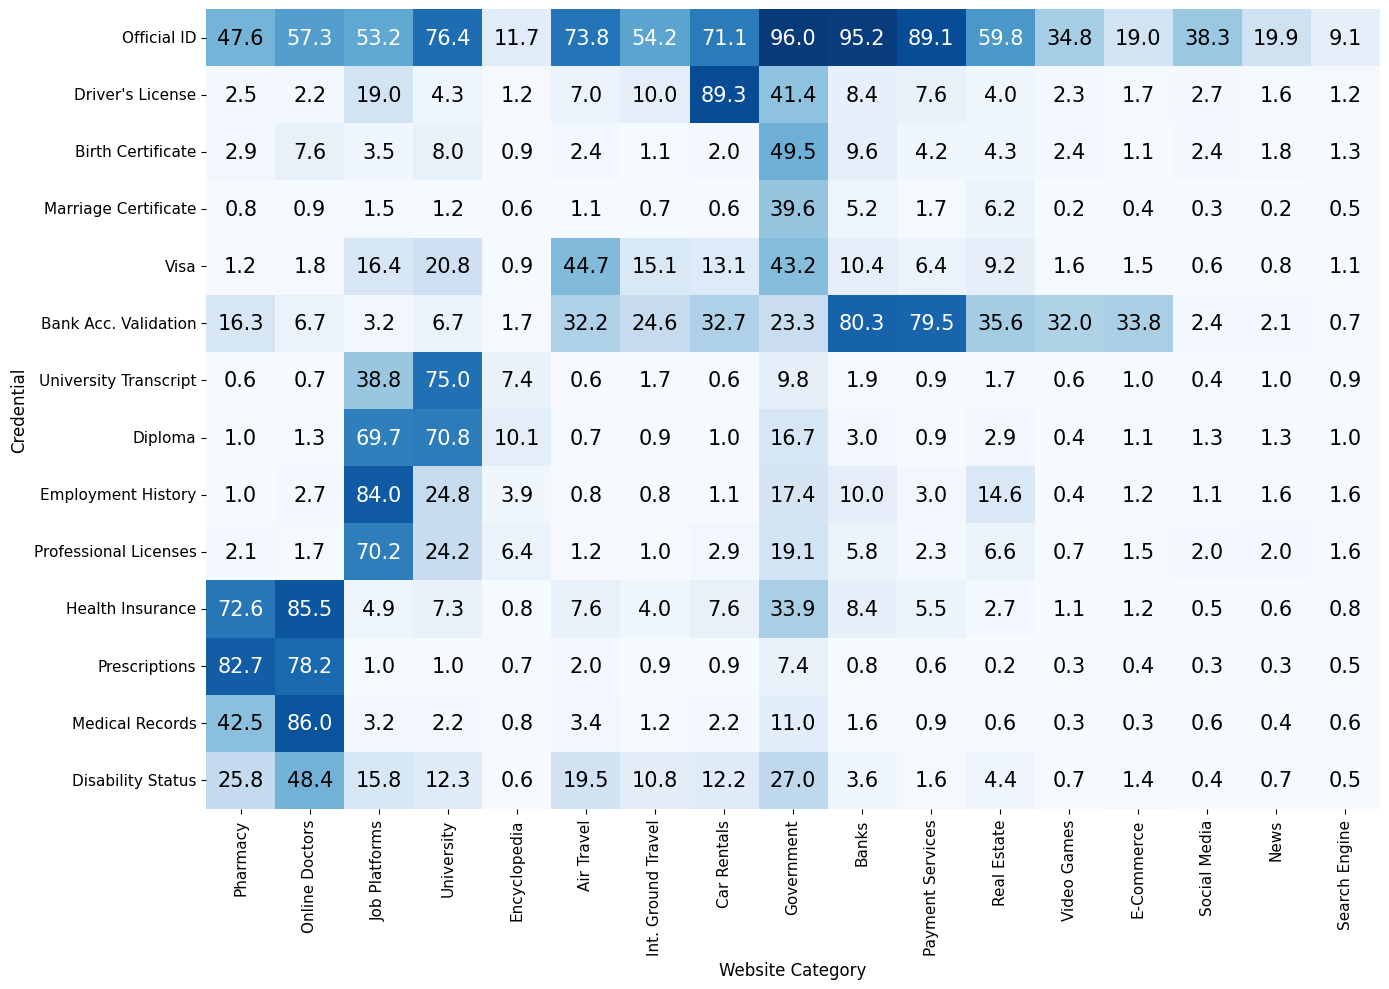

Saved: charts/credential_percentage_per_category_heatmap.pdf


In [4]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=False, cmap='Blues', 
            cbar=False, ax=ax, vmin=0, vmax=100)

# Add custom annotations without % symbol
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        # Use white text for darker backgrounds (higher values), black for lighter backgrounds
        text_color = 'white' if value > 50 else 'black'
        ax.text(j + 0.5, i + 0.5, f'{value:.1f}', ha='center', va='center', 
            color=text_color, fontsize=15)

ax.set_xlabel('Website Category', fontsize=12)
ax.set_ylabel('Credential', fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.savefig('charts/credential_percentage_per_category_heatmap.pdf', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: charts/credential_percentage_per_category_heatmap.pdf")

## Generate user study vs. survey oversharing figures

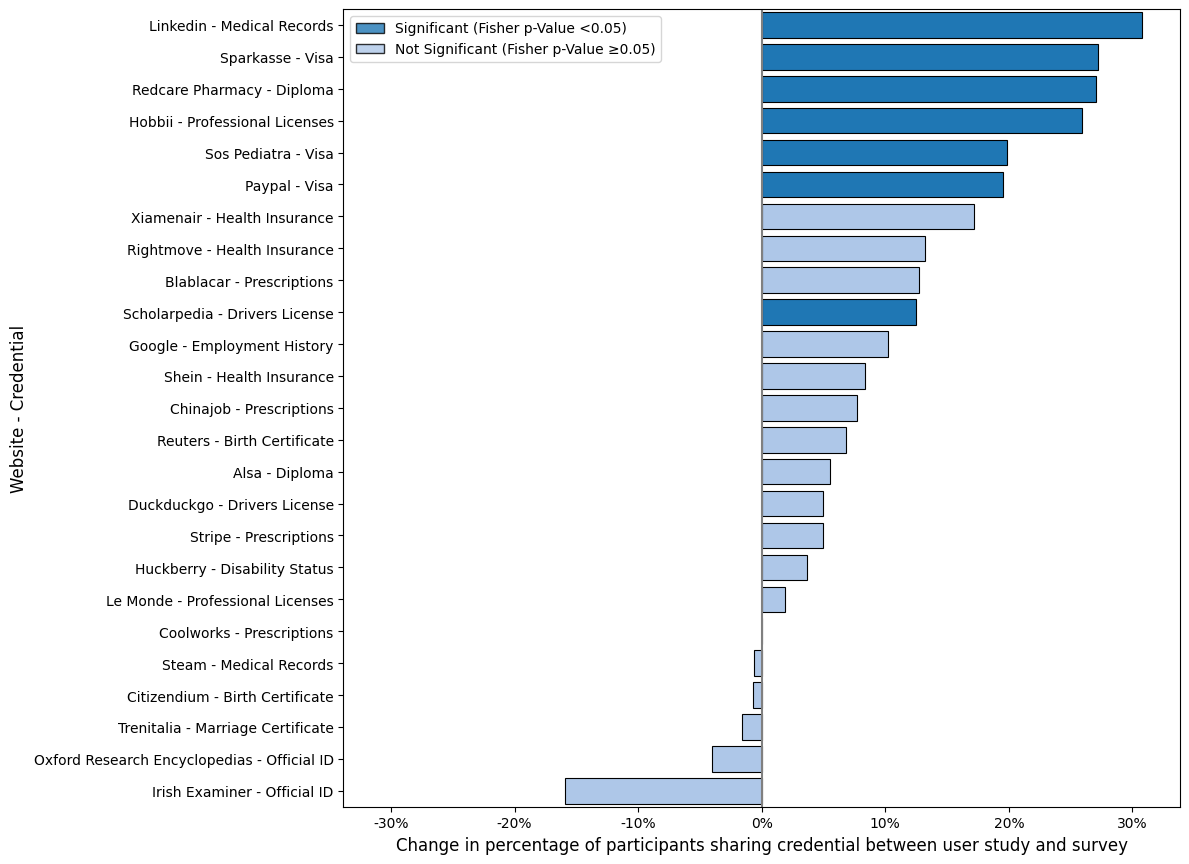

Saved: charts/user_study_vs_survey_difference_no_justification_scenarios.pdf


In [5]:
phase_s235_df = pd.read_csv('tables/user_study_no_justification.csv')

phase_s235_df['Control %'] = phase_s235_df['Control %'].str.rstrip('%').astype(float)
phase_s235_df['Phase 1 %'] = phase_s235_df['Phase 1 %'].str.rstrip('%').astype(float)

phase_s235_df['diff_pct'] = phase_s235_df['Control %'] - phase_s235_df['Phase 1 %']

phase_s235_df['label'] = phase_s235_df['Website'].str.strip() + ' - ' + phase_s235_df['Requested Credential'].str.strip()

# Capitalize 'Id' to 'ID'
phase_s235_df['label'] = phase_s235_df['label'].str.replace('Id', 'ID')

# Significance flag
phase_s235_df['significant'] = phase_s235_df['P Value'] < 0.05

phase_s235_df = phase_s235_df.sort_values('diff_pct')

colors_s235 = ['#1f77b4' if sig else '#aec7e8' for sig in phase_s235_df['significant']]

height_s235 = max(6, 0.35 * len(phase_s235_df))
fig, ax = plt.subplots(figsize=(12, height_s235))

ax.barh(phase_s235_df['label'], phase_s235_df['diff_pct'], color=colors_s235, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs_s235 = max(abs(phase_s235_df['diff_pct'].min()), abs(phase_s235_df['diff_pct'].max()))
ax.set_xlim(-max_abs_s235 * 1.1, max_abs_s235 * 1.1)

ax.set_ylim(-0.5, len(phase_s235_df) - 0.5)

ax.set_xlabel('Change in percentage of participants sharing credential between user study and survey', fontsize=12)
ax.set_ylabel('Website - Credential', fontsize=12)

legend_elements_s235 = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Fisher p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Fisher p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_s235, fontsize=10, loc='best')

plt.tight_layout()

diff_chart_s235_path = 'charts/user_study_vs_survey_difference_no_justification_scenarios.pdf'
plt.savefig(diff_chart_s235_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {diff_chart_s235_path}")

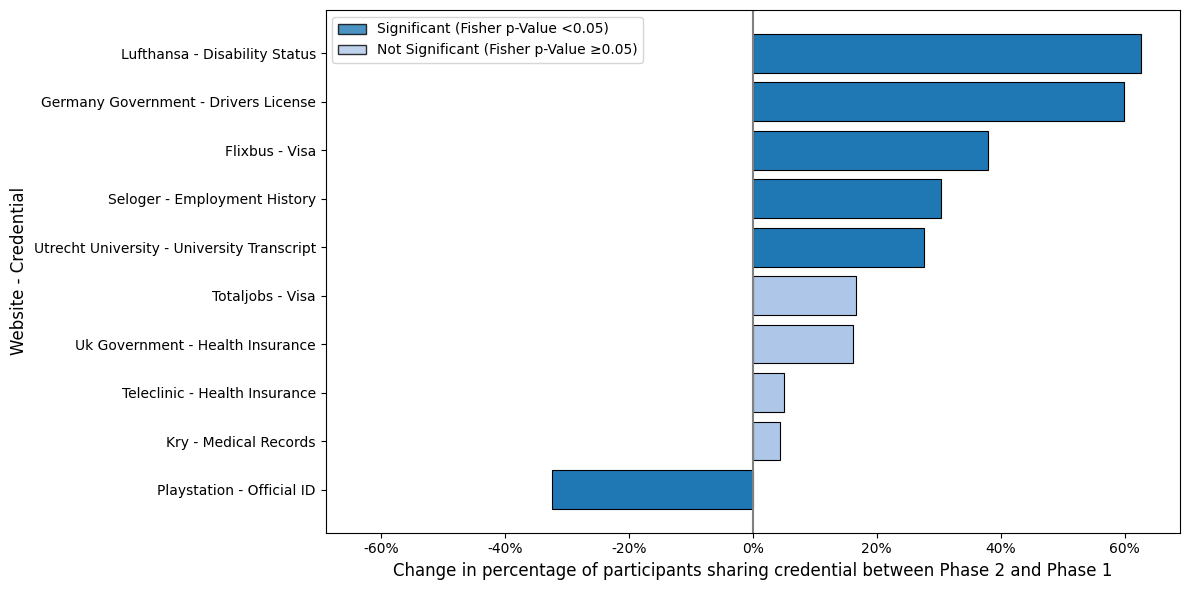

Saved: charts/user_study_vs_survey_difference_uncertain_justification_scenarios.pdf


In [6]:
phase_df = pd.read_csv('tables/user_study_uncertain_justification.csv')

phase_df['Control %'] = phase_df['Control %'].str.rstrip('%').astype(float)
phase_df['Phase 1 %'] = phase_df['Phase 1 %'].str.rstrip('%').astype(float)

phase_df['diff_pct'] = phase_df['Control %'] - phase_df['Phase 1 %']

phase_df['label'] = phase_df['Website'].str.strip() + ' - ' + phase_df['Requested Credential'].str.strip()

# Capitalize 'Id' to 'ID'
phase_df['label'] = phase_df['label'].str.replace('Id', 'ID')

# Significance flag
phase_df['significant'] = phase_df['P Value'] < 0.05

phase_df = phase_df.sort_values('diff_pct')

colors = ['#1f77b4' if sig else '#aec7e8' for sig in phase_df['significant']]

height = max(6, 0.35 * len(phase_df))
fig, ax = plt.subplots(figsize=(12, height))

ax.barh(phase_df['label'], phase_df['diff_pct'], color=colors, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs = max(abs(phase_df['diff_pct'].min()), abs(phase_df['diff_pct'].max()))
ax.set_xlim(-max_abs * 1.1, max_abs * 1.1)

ax.set_xlabel('Change in percentage of participants sharing credential between Phase 2 and Phase 1', fontsize=12)
ax.set_ylabel('Website - Credential', fontsize=12)

legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Fisher p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Fisher p-Value ≥0.05)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='best')

plt.tight_layout()

diff_chart_path = 'charts/user_study_vs_survey_difference_uncertain_justification_scenarios.pdf'
plt.savefig(diff_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {diff_chart_path}")

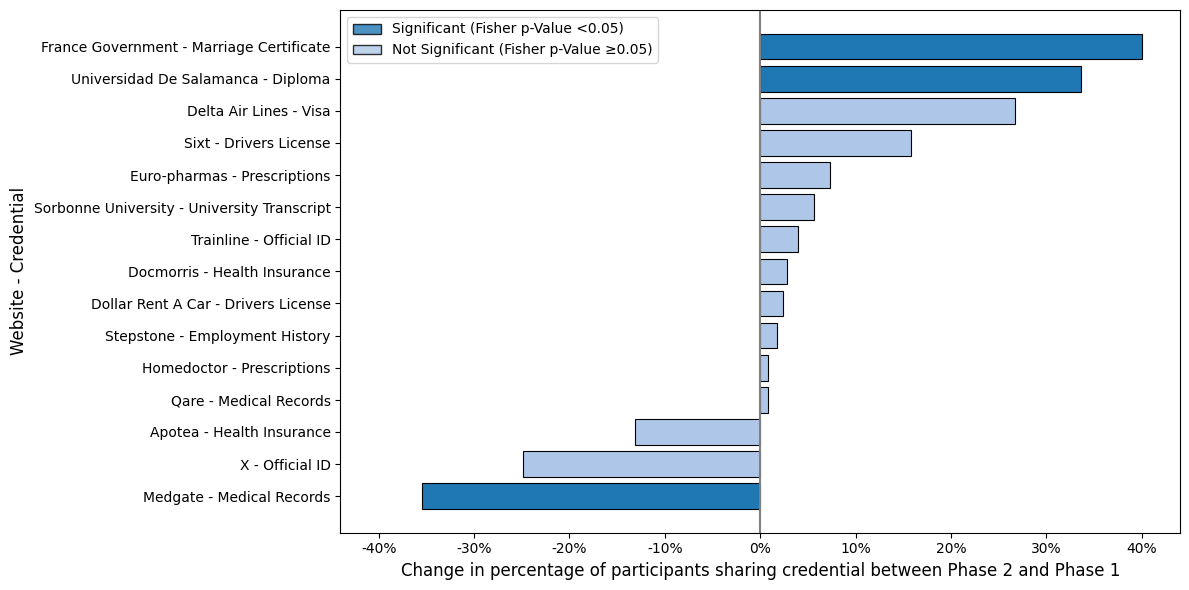

Saved: charts/user_study_vs_survey_difference_good_justification_scenarios.pdf


In [7]:
phase_s46_df = pd.read_csv('tables/user_study_good_justification.csv')

phase_s46_df['Control %'] = phase_s46_df['Control %'].str.rstrip('%').astype(float)
phase_s46_df['Phase 1 %'] = phase_s46_df['Phase 1 %'].str.rstrip('%').astype(float)

phase_s46_df['diff_pct'] = phase_s46_df['Control %'] - phase_s46_df['Phase 1 %']

phase_s46_df['label'] = phase_s46_df['Website'].str.strip() + ' - ' + phase_s46_df['Requested Credential'].str.strip()

# Capitalize 'Id' to 'ID'
phase_s46_df['label'] = phase_s46_df['label'].str.replace('Id', 'ID')

# Significance flag
phase_s46_df['significant'] = phase_s46_df['P Value'] < 0.05

phase_s46_df = phase_s46_df.sort_values('diff_pct')

colors_s46 = ['#1f77b4' if sig else '#aec7e8' for sig in phase_s46_df['significant']]

height_s46 = max(6, 0.35 * len(phase_s46_df))
fig, ax = plt.subplots(figsize=(12, height_s46))

ax.barh(phase_s46_df['label'], phase_s46_df['diff_pct'], color=colors_s46, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs_s46 = max(abs(phase_s46_df['diff_pct'].min()), abs(phase_s46_df['diff_pct'].max()))
ax.set_xlim(-max_abs_s46 * 1.1, max_abs_s46 * 1.1)

ax.set_xlabel('Change in percentage of participants sharing credential between Phase 2 and Phase 1', fontsize=12)
ax.set_ylabel('Website - Credential', fontsize=12)

legend_elements_s46 = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Fisher p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Fisher p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_s46, fontsize=10, loc='best')

plt.tight_layout()

diff_chart_s46_path = 'charts/user_study_vs_survey_difference_good_justification_scenarios.pdf'
plt.savefig(diff_chart_s46_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {diff_chart_s46_path}")

## Generate the Figures comparing the number of users who chose a credential for different countries and traffic sizes

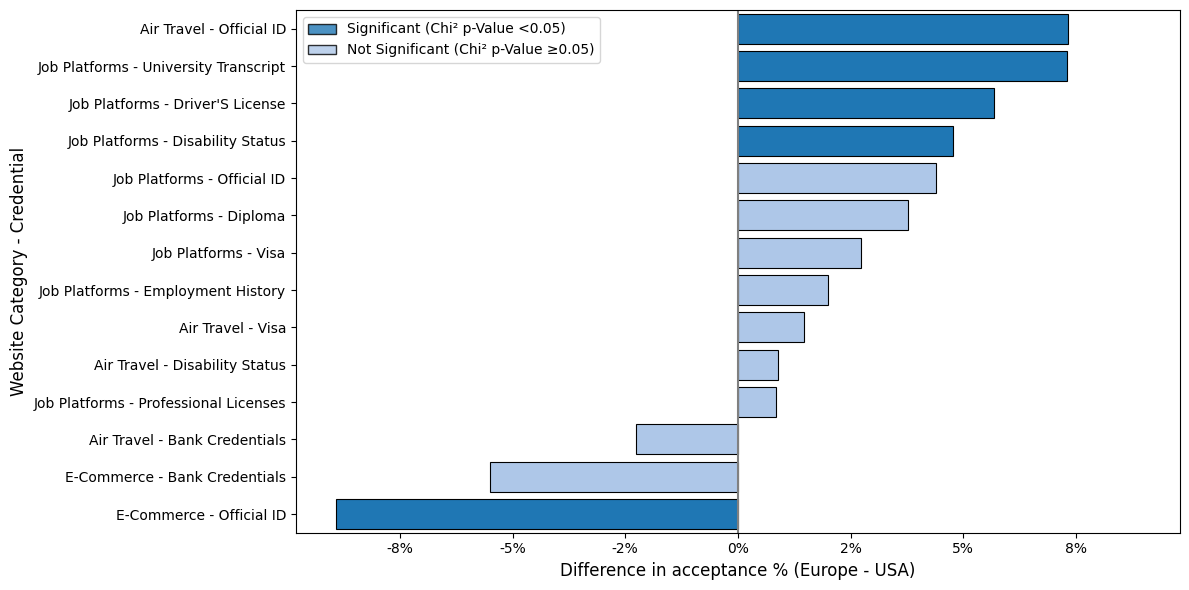

Saved: charts/chi2_europe_vs_usa_comparison.pdf


In [8]:
# Europe vs USA comparison
eu_usa_df = pd.read_csv('tables/chi2_europe_vs_usa.csv')

eu_usa_df['Europe Accept %'] = eu_usa_df['Europe Accept %'].str.rstrip('%').astype(float)
eu_usa_df['USA Accept %'] = eu_usa_df['USA Accept %'].str.rstrip('%').astype(float)

# Filter: remove rows where BOTH Europe AND USA % are <= 10%
eu_usa_df = eu_usa_df[~((eu_usa_df['Europe Accept %'] <= 10) & (eu_usa_df['USA Accept %'] <= 10))].copy()

# Compute difference: Europe % - USA %
eu_usa_df['diff_pct'] = eu_usa_df['Europe Accept %'] - eu_usa_df['USA Accept %']

# Rename 'Official Identity Document' to 'Official ID'
eu_usa_df['Credential'] = eu_usa_df['Credential'].str.replace('Official Identity Document', 'Official ID')

# Capitalize all credential names
eu_usa_df['Credential'] = eu_usa_df['Credential'].str.title()

# Create label: Website category - Credential
eu_usa_df['label'] = eu_usa_df['Website category'].str.strip() + ' - ' + eu_usa_df['Credential'].str.strip()

# Capitalize 'Id' to 'ID' in labels
eu_usa_df['label'] = eu_usa_df['label'].str.replace('Id', 'ID')

# Significance flag: p-Value < 0.05
eu_usa_df['significant'] = eu_usa_df['p-Value'] < 0.05

eu_usa_df = eu_usa_df.sort_values('diff_pct')

colors_eu_usa = ['#1f77b4' if sig else '#aec7e8' for sig in eu_usa_df['significant']]

height_eu_usa = max(6, 0.35 * len(eu_usa_df))
fig, ax = plt.subplots(figsize=(12, height_eu_usa))

ax.barh(eu_usa_df['label'], eu_usa_df['diff_pct'], color=colors_eu_usa, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs_eu_usa = max(abs(eu_usa_df['diff_pct'].min()), abs(eu_usa_df['diff_pct'].max()))
ax.set_xlim(-max_abs_eu_usa * 1.1, max_abs_eu_usa * 1.1)

ax.set_ylim(-0.5, len(eu_usa_df) - 0.5)

ax.set_xlabel('Difference in acceptance % (Europe - USA)', fontsize=12)
ax.set_ylabel('Website Category - Credential', fontsize=12)

legend_elements_eu_usa = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Chi² p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Chi² p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_eu_usa, fontsize=10, loc='best')

plt.tight_layout()

eu_usa_chart_path = 'charts/chi2_europe_vs_usa_comparison.pdf'
plt.savefig(eu_usa_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {eu_usa_chart_path}")

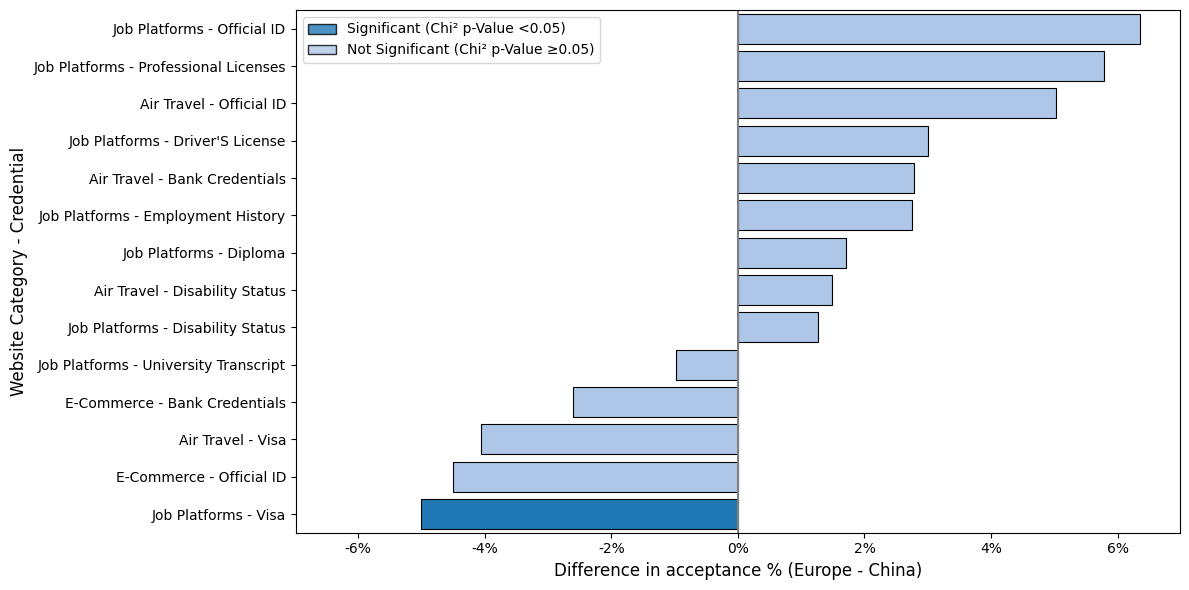

Saved: charts/chi2_europe_vs_china_comparison.pdf


In [9]:
# Europe vs China comparison
eu_china_df = pd.read_csv('tables/chi2_europe_vs_china.csv')

eu_china_df['Europe Accept %'] = eu_china_df['Europe Accept %'].str.rstrip('%').astype(float)
eu_china_df['China Accept %'] = eu_china_df['China Accept %'].str.rstrip('%').astype(float)

# Filter: remove rows where BOTH Europe AND China % are <= 10%
eu_china_df = eu_china_df[~((eu_china_df['Europe Accept %'] <= 10) & (eu_china_df['China Accept %'] <= 10))].copy()

# Compute difference: Europe % - China %
eu_china_df['diff_pct'] = eu_china_df['Europe Accept %'] - eu_china_df['China Accept %']

# Rename 'Official Identity Document' to 'Official ID'
eu_china_df['Credential'] = eu_china_df['Credential'].str.replace('Official Identity Document', 'Official ID')

# Capitalize all credential names
eu_china_df['Credential'] = eu_china_df['Credential'].str.title()

# Create label: Website category - Credential
eu_china_df['label'] = eu_china_df['Website category'].str.strip() + ' - ' + eu_china_df['Credential'].str.strip()

# Capitalize 'Id' to 'ID' in labels
eu_china_df['label'] = eu_china_df['label'].str.replace('Id', 'ID')

# Significance flag: p-Value < 0.05
eu_china_df['significant'] = eu_china_df['p-Value'] < 0.05

eu_china_df = eu_china_df.sort_values('diff_pct')

colors_eu_china = ['#1f77b4' if sig else '#aec7e8' for sig in eu_china_df['significant']]

height_eu_china = max(6, 0.35 * len(eu_china_df))
fig, ax = plt.subplots(figsize=(12, height_eu_china))

ax.barh(eu_china_df['label'], eu_china_df['diff_pct'], color=colors_eu_china, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs_eu_china = max(abs(eu_china_df['diff_pct'].min()), abs(eu_china_df['diff_pct'].max()))
ax.set_xlim(-max_abs_eu_china * 1.1, max_abs_eu_china * 1.1)

ax.set_ylim(-0.5, len(eu_china_df) - 0.5)

ax.set_xlabel('Difference in acceptance % (Europe - China)', fontsize=12)
ax.set_ylabel('Website Category - Credential', fontsize=12)

legend_elements_eu_china = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Chi² p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Chi² p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_eu_china, fontsize=10, loc='best')

plt.tight_layout()

eu_china_chart_path = 'charts/chi2_europe_vs_china_comparison.pdf'
plt.savefig(eu_china_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {eu_china_chart_path}")

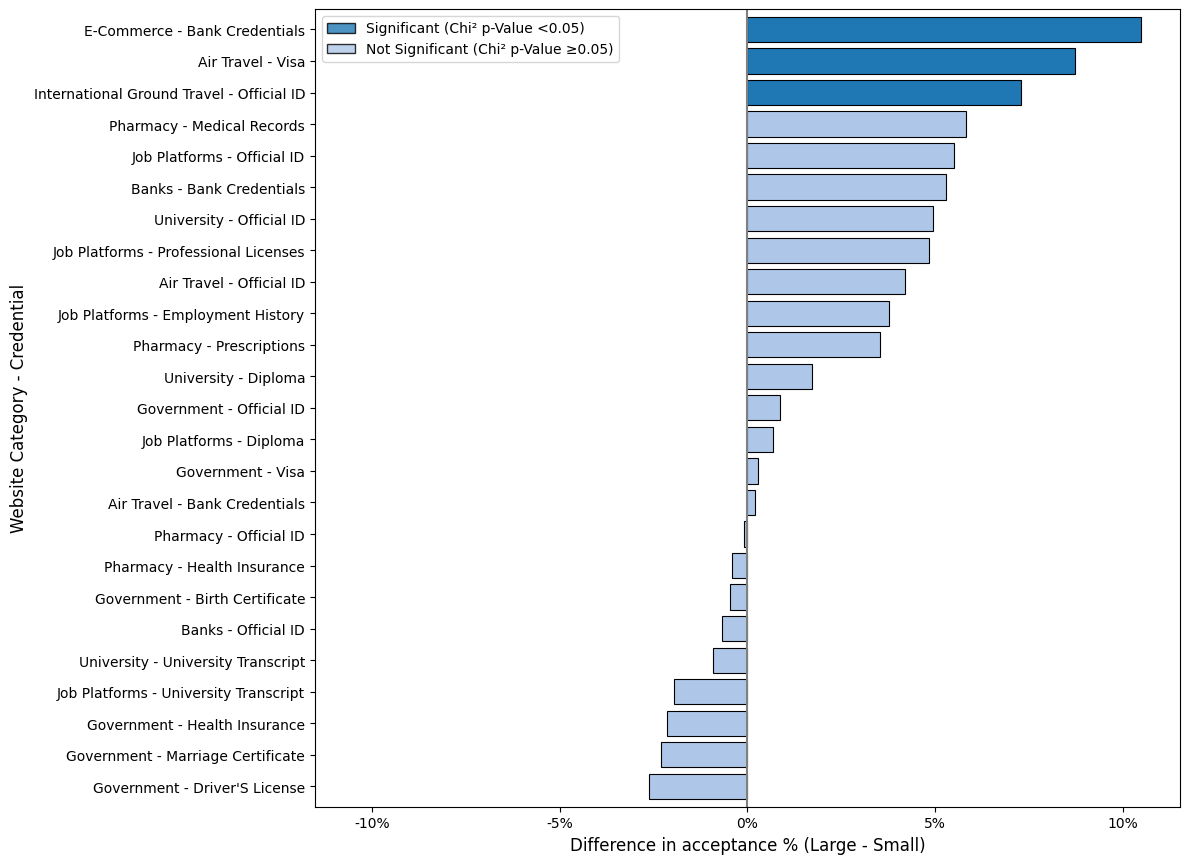

Saved: charts/chi2_large_vs_small_comparison.pdf


In [10]:
# Large vs Small comparison
large_small_df = pd.read_csv('tables/chi2_large_vs_small.csv')

# Clean percentage columns (remove '%' and cast to float)
large_small_df['Large Accept %'] = large_small_df['Large Accept %'].str.rstrip('%').astype(float)
large_small_df['Small Accept %'] = large_small_df['Small Accept %'].str.rstrip('%').astype(float)

# Filter: keep only rows where Large % >= 30% OR Small % >= 30%, and exclude NaN values
large_small_df = large_small_df[((large_small_df['Large Accept %'] >= 30) | (large_small_df['Small Accept %'] >= 30))].copy()
large_small_df = large_small_df.dropna(subset=['Large Accept %', 'Small Accept %'])

# Remove all Car Rentals rows (as this did not have medium websites)
large_small_df = large_small_df[large_small_df['Website category'] != 'Car Rentals']

# Compute difference: Large % - Small %
large_small_df['diff_pct'] = large_small_df['Large Accept %'] - large_small_df['Small Accept %']

# Rename 'Official Identity Document' to 'Official ID'
large_small_df['Credential'] = large_small_df['Credential'].str.replace('Official Identity Document', 'Official ID')

# Capitalize all credential names
large_small_df['Credential'] = large_small_df['Credential'].str.title()

# Create label: Website category - Credential
large_small_df['label'] = large_small_df['Website category'].str.strip() + ' - ' + large_small_df['Credential'].str.strip()

# Capitalize 'Id' to 'ID' in labels
large_small_df['label'] = large_small_df['label'].str.replace('Id', 'ID')

# Significance flag: p-Value < 0.05
large_small_df['significant'] = large_small_df['p-Value'] < 0.05

large_small_df = large_small_df.sort_values('diff_pct')

colors_large_small = ['#1f77b4' if sig else '#aec7e8' for sig in large_small_df['significant']]

height_large_small = max(6, 0.35 * len(large_small_df))
fig, ax = plt.subplots(figsize=(12, height_large_small))

ax.barh(large_small_df['label'], large_small_df['diff_pct'], color=colors_large_small, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs_large_small = max(abs(large_small_df['diff_pct'].min()), abs(large_small_df['diff_pct'].max()))
ax.set_xlim(-max_abs_large_small * 1.1, max_abs_large_small * 1.1)

ax.margins(y=0.01)

ax.set_xlabel('Difference in acceptance % (Large - Small)', fontsize=12)
ax.set_ylabel('Website Category - Credential', fontsize=12)

legend_elements_large_small = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Chi² p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Chi² p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_large_small, fontsize=10, loc='best')

plt.tight_layout()

large_small_chart_path = 'charts/chi2_large_vs_small_comparison.pdf'
plt.savefig(large_small_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {large_small_chart_path}")

## Generate user disagreement per category website heatmap

In [11]:
raw_df = pd.read_csv('tables/credential_percentage_per_website.csv')

value_cols = [c for c in raw_df.columns if c != 'Website']
clean_df = raw_df.copy()
for col in value_cols:
    clean_df[col] = clean_df[col].str.rstrip('%').astype(float) / 100.0

print(f"Websites: {clean_df['Website'].nunique()}")
print(f"Credentials: {len(value_cols)}\n")
print(clean_df.head())

Websites: 166
Credentials: 14

            Website  Bank credentials  Birth certificate  Diploma  \
0         DocMorris            0.1643             0.0571   0.0214   
1  Redcare Pharmacy            0.1953             0.0469   0.0156   
2         NewPharma            0.0952             0.0238   0.0079   
3            Apotea            0.1565             0.0348   0.0000   
4        Pharmacy2U            0.1611             0.0336   0.0000   

   Disability status  Driver's license  Employment history  Health insurance  \
0             0.2143            0.0214              0.0214            0.7500   
1             0.3047            0.0156              0.0312            0.6953   
2             0.2143            0.0317              0.0000            0.7381   
3             0.3043            0.0261              0.0087            0.7217   
4             0.2953            0.0336              0.0000            0.7852   

   Marriage certificate  Medical records  Official Identity Document  \
0

In [12]:
website_category_map = {
    # Pharmacy
    'DocMorris': 'Pharmacy',
    'Redcare Pharmacy': 'Pharmacy',
    'NewPharma': 'Pharmacy',
    'Apotea': 'Pharmacy',
    'Pharmacy2U': 'Pharmacy',
    'Apteka Gemini': 'Pharmacy',
    'Farmacias': 'Pharmacy',
    'Farmacia Loreto Gallo': 'Pharmacy',
    'Euro-Pharmas': 'Pharmacy',

    # Online Doctors / Telehealth
    'Homedoctor': 'Online Doctors',
    'Qare': 'Online Doctors',
    'Kry': 'Online Doctors',
    'Teleclinic': 'Online Doctors',
    'SoS Pediatra': 'Online Doctors',
    'Medgate': 'Online Doctors',

    # Government
    'Official Government Website of Germany': 'Government',
    'Official Government Website of France': 'Government',
    'Official Government Website of Italy': 'Government',
    'Official Government Website of the UK': 'Government',
    'Official Government Website of Denmark': 'Government',
    'Official Government Website of the Netherlands': 'Government',
    'Official Government Website of Poland': 'Government',
    'Official Government Website of Lithuania': 'Government',
    'Official Government Website of Estonia': 'Government',

    # Ground travel / intercity
    'Flixbus': 'Ground Travel',
    'Blablacar': 'Ground Travel',
    'Trainline': 'Ground Travel',
    'Trenitalia': 'Ground Travel',
    'Eurail': 'Ground Travel',
    'Alsa': 'Ground Travel',
    'Ecolines': 'Ground Travel',
    'RegioJet': 'Ground Travel',
    'Faniani Coaches': 'Ground Travel',

    # Banking
    'HSBC': 'Bank',
    'ABN Amro': 'Bank',
    'Sparkasse': 'Bank',
    'Sella': 'Bank',
    'AIB Group': 'Bank',
    'Handelsbanken': 'Bank',
    'Bank of Valletta': 'Bank',
    'Cecabank': 'Bank',
    'Islandsbanki': 'Bank',

    # Real Estate
    'Immobiliare': 'Real Estate',
    'SeLoger': 'Real Estate',
    'ImmoScout24': 'Real Estate',
    'Rightmove': 'Real Estate',
    'Hemnet': 'Real Estate',
    'Immoweb': 'Real Estate',

    # Universities
    'Ludwig Maximilian University of Munich': 'University',
    'Utrecht University': 'University',
    'Sorbonne University': 'University',
    'Universidad de Salamanca': 'University',
    'Central European University': 'University',
    'University of Warsaw': 'University',
    'University of Luxembourg': 'University',
    'Liszt Academy of Music': 'University',
    'Aarhus School of Architecture': 'University',

    # News
    'Reuters': 'News',
    'Le Monde': 'News',
    'Der Standard': 'News',
    'Irish Examiner': 'News',
    'Digi24': 'News',
    'Delo': 'News',
    'Ekathimerini': 'News',
    'Expresso': 'News',
    'The Shift News': 'News',

    # Car Rental
    'Europcar': 'Car Rental',
    'Sixt': 'Car Rental',
    'Hertz': 'Car Rental',
    'Avis': 'Car Rental',
    'Alamo': 'Car Rental',
    'Greenmotion': 'Car Rental',
    'Cambio CarSharing': 'Car Rental',
    'ACE Rent A Car': 'Car Rental',
    'Thrifty Car Rental': 'Car Rental',
    'Dollar Rent A Car': 'Car Rental',

    # Gaming
    'Steam': 'Gaming',
    'Epic Games': 'Gaming',
    'Ubisoft': 'Gaming',
    'Playstation': 'Gaming',
    'Nintendo': 'Gaming',
    'GOG.com': 'Gaming',

    # Social Media
    'Facebook': 'Social Media',
    'X': 'Social Media',
    'Instagram': 'Social Media',
    'Snapchat': 'Social Media',
    'TikTok': 'Social Media',
    'Bluesky': 'Social Media',

    # Encyclopedias / knowledge sites
    'Wikipedia': 'Encyclopedia',
    'Encyclopædia Britannica': 'Encyclopedia',
    'Oxford Research Encyclopedias': 'Encyclopedia',
    'Encyclopedia.com': 'Encyclopedia',
    'Citizendium': 'Encyclopedia',
    'World Book Online': 'Encyclopedia',
    'InfoPlease': 'Encyclopedia',
    'Scholarpedia': 'Encyclopedia',
    'KnowledgePicker': 'Encyclopedia',

    # Search engines
    'Google': 'Search Engine',
    'DuckDuckGo': 'Search Engine',
    'Ecosia': 'Search Engine',
    'Swisscows': 'Search Engine',
    'Dogpile': 'Search Engine',
    'Disconnect Search': 'Search Engine',
    'Mojeek': 'Search Engine',
    'Giburu': 'Search Engine',
    'MetaGer': 'Search Engine',

    # Payment services
    'Paypal': 'Payment Services',
    'Stripe': 'Payment Services',
    'Square': 'Payment Services',
    'Skrill': 'Payment Services',
    'Payoneer': 'Payment Services',
    'Wise': 'Payment Services',

    # Job portals
    'Totaljobs': 'Job Portal',
    'Stepstone': 'Job Portal',
    'Jobindex': 'Job Portal',
    'Profesia': 'Job Portal',
    'Jobs.ie': 'Job Portal',
    'Prace': 'Job Portal',
    'Indeed': 'Job Portal',
    'LinkedIn': 'Job Portal',
    'We Work Remotely': 'Job Portal',
    'Ladders': 'Job Portal',
    'ClearanceJobs': 'Job Portal',
    'CoolWorks': 'Job Portal',
    'eChinaCities': 'Job Portal',
    'ChinaJob': 'Job Portal',
    'HiredChina': 'Job Portal',
    'LaowaiCareer': 'Job Portal',
    'Lockin China': 'Job Portal',
    'ExpatJobs': 'Job Portal',

    # Air Travel
    'Lufthansa': 'Air Travel',
    'Pegasus Airlines': 'Air Travel',
    'British Airways': 'Air Travel',
    'Blue Air': 'Air Travel',
    'Lauda Europe': 'Air Travel',
    'Braathens Regional Airlines': 'Air Travel',
    'Delta Air Lines': 'Air Travel',
    'Hawaiian Airlines': 'Air Travel',
    'Spirit Airlines': 'Air Travel',
    'Avelo Airlines': 'Air Travel',
    'Silver Airways': 'Air Travel',
    'Southern Airways Express': 'Air Travel',
    'Air China': 'Air Travel',
    'XiamenAir': 'Air Travel',
    'China Southern Airlines': 'Air Travel',
    'Juneyao Airlines': 'Air Travel',
    'Shenzhen Airlines': 'Air Travel',
    '9 Air': 'Air Travel',

    # E-commerce / retail
    'Zalando': 'E-commerce',
    'ASOS': 'E-commerce',
    'Hobbii': 'E-commerce',
    'eMAG': 'E-commerce',
    'Verkkokauppa.com': 'E-commerce',
    'Ravensburger': 'E-commerce',
    'Amazon': 'E-commerce',
    'Etsy': 'E-commerce',
    'Overstock': 'E-commerce',
    'Bookshop.org': 'E-commerce',
    'Huckberry': 'E-commerce',
    'Rifle Paper Co.': 'E-commerce',
    'AliExpress': 'E-commerce',
    'Banggood': 'E-commerce',
    'Tomtop': 'E-commerce',
    'Shein': 'E-commerce',
    'MiniInTheBox': 'E-commerce',
    'Chinavasion': 'E-commerce',
}

clean_df['category'] = clean_df['Website'].map(website_category_map)
missing = clean_df[clean_df['category'].isna()]['Website'].unique()
print(f"Unmapped websites: {len(missing)}")
if len(missing) > 0:
    print(missing)

Unmapped websites: 0


In [13]:
long_df = clean_df.melt(id_vars=['Website', 'category'], var_name='credential', value_name='share')
long_df = long_df.dropna(subset=['category'])

print(f"Rows after mapping: {len(long_df)}")

def iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return q3 - q1

metrics = long_df.groupby(['category', 'credential']).agg(
    n_sites=('Website', 'nunique'),
    mean_share=('share', 'mean'),
    std_share=('share', 'std'),
    min_share=('share', 'min'),
    max_share=('share', 'max'),
    iqr_share=('share', iqr)
).reset_index()

metrics['range_share'] = metrics['max_share'] - metrics['min_share']
metrics['coef_var'] = metrics['std_share'] / metrics['mean_share']

print("Disagreement metrics (first 15 rows):")
print(metrics.head(15))

Rows after mapping: 2324
Disagreement metrics (first 15 rows):
      category                  credential  n_sites  mean_share  std_share  \
0   Air Travel            Bank credentials       18    0.323250   0.050689   
1   Air Travel           Birth certificate       18    0.023811   0.022800   
2   Air Travel                     Diploma       18    0.007267   0.006764   
3   Air Travel           Disability status       18    0.193694   0.033783   
4   Air Travel            Driver's license       18    0.071083   0.026369   
5   Air Travel          Employment history       18    0.007756   0.007614   
6   Air Travel            Health insurance       18    0.075089   0.033705   
7   Air Travel        Marriage certificate       18    0.011094   0.006845   
8   Air Travel             Medical records       18    0.035050   0.016551   
9   Air Travel  Official Identity Document       18    0.737361   0.067525   
10  Air Travel               Prescriptions       18    0.020372   0.018725   
1

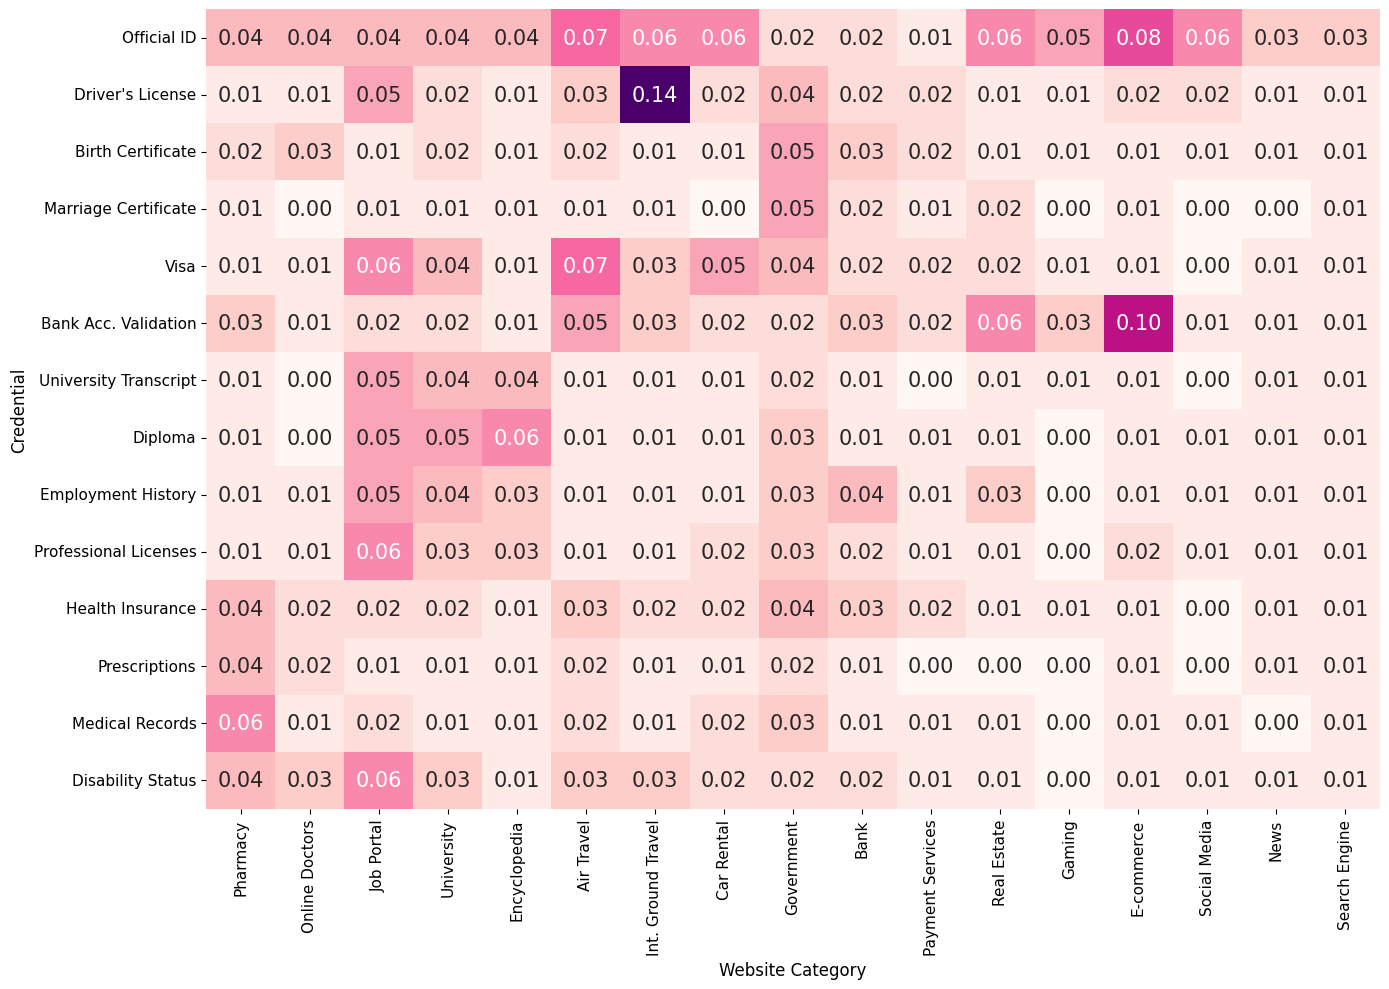

Saved: charts/non_expert_disagreement_heatmap.pdf


In [14]:
# Heatmap of disagreement (std) by credential × category
heatmap_df = metrics.pivot(index='credential', columns='category', values='std_share')

category_order = ['Pharmacy', 'Online Doctors', 'Job Portal', 'University', 'Encyclopedia', 
                  'Air Travel', 'Int. Ground Travel', 'Car Rental', 'Government', 'Bank', 
                  'Payment Services', 'Real Estate', 'Gaming', 'E-commerce', 'Social Media', 
                  'News', 'Search Engine']
# Rename 'Ground Travel' to 'Int. Ground Travel' if it exists
if 'Ground Travel' in heatmap_df.columns:
    heatmap_df.rename(columns={'Ground Travel': 'Int. Ground Travel'}, inplace=True)
heatmap_df = heatmap_df[category_order]

# Rename 'Official Identity Document' to 'Official ID'
heatmap_df.rename(index={'Official Identity Document': 'Official ID'}, inplace=True)

# Capitalize all words in credential names
heatmap_df.index = heatmap_df.index.str.title()

# Fix 'Official Id' to 'Official ID'
heatmap_df.rename(index={'Official Id': 'Official ID'}, inplace=True)

# Rename 'Bank Credentials' to 'Bank Acc. Validation'
heatmap_df.rename(index={'Bank Credentials': 'Bank Acc. Validation'}, inplace=True)

# Fix "Driver'S License" to "Driver's License"
heatmap_df.rename(index={"Driver'S License": "Driver's License"}, inplace=True)

credential_order = ['Official ID', "Driver's License", 'Birth Certificate', 
                    'Marriage Certificate', 'Visa', 'Bank Acc. Validation', 'University Transcript', 
                    'Diploma', 'Employment History', 'Professional Licenses', 
                    'Health Insurance', 'Prescriptions', 'Medical Records', 'Disability Status']
heatmap_df = heatmap_df.reindex(credential_order)

heatmap_df = heatmap_df.round(2)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdPu', cbar=False, ax=ax,
            annot_kws={'fontsize': 15})
ax.set_xlabel('Website Category', fontsize=12)
ax.set_ylabel('Credential', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=11)
plt.tight_layout()
plt.savefig('charts/non_expert_disagreement_heatmap.pdf', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: charts/non_expert_disagreement_heatmap.pdf")

## Figures showing user behavior change

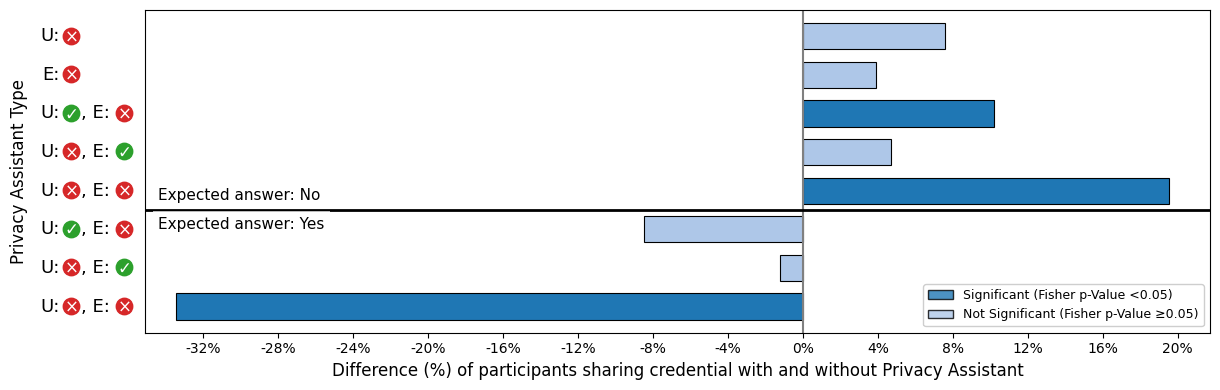

Saved: charts/user_study_mistakes_increase.pdf


In [15]:
mistakes_df = pd.read_csv('files/user_study_mistakes_increase_table_fisher.csv')

mistakes_df['Diff yes %'] = mistakes_df['Diff yes %'].str.rstrip('%').astype(float)

mistakes_df['Diff yes %'] = -mistakes_df['Diff yes %']

mistakes_df['label'] = mistakes_df['Group'].str.replace(
    'and', 'and\n'
).str.replace(
    '(', '\n('
).str.strip()

# Significance flag
mistakes_df['significant'] = mistakes_df['p-Value (Fisher)'] < 0.05

mistakes_df = mistakes_df.iloc[::-1].reset_index(drop=True)

colors_mistakes = ['#1f77b4' if sig else '#aec7e8' for sig in mistakes_df['significant']]

height_mistakes = max(4.0, 0.22 * len(mistakes_df))
fig, ax = plt.subplots(figsize=(12, height_mistakes))

y_step = 0.56
bar_height = 0.38
y_positions = [i * y_step for i in range(len(mistakes_df))]

ax.barh(y_positions, mistakes_df['Diff yes %'], color=colors_mistakes, edgecolor='black', linewidth=0.8, height=bar_height)
ax.set_yticks(y_positions)
ax.set_yticklabels(mistakes_df['label'])
ax.margins(y=0.002)
ax.set_ylim(-bar_height, y_positions[-1] + bar_height)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

# Add separator line between S5 and S6
last_s5_index = None
first_s6_index = None

for i, label in enumerate(mistakes_df['label']):
    if 'S5' in label:
        last_s5_index = i
    elif 'S6' in label and first_s6_index is None:
        first_s6_index = i

separator_y = None
if last_s5_index is not None and first_s6_index is not None:
    separator_y = (y_positions[last_s5_index] + y_positions[first_s6_index]) / 2
    ax.axhline(y=separator_y, color='black', linestyle='-', linewidth=2, zorder=10)

# Override y-axis labels for Privacy Assistant Type with custom red X and green checkmark icons
label_specs_top_to_bottom = [
    {'left': 'U:', 'left_icon': 'cross', 'right': None, 'right_icon': None},
    {'left': 'E:', 'left_icon': 'cross', 'right': None, 'right_icon': None},
    {'left': 'U:', 'left_icon': 'tick', 'right': 'E:', 'right_icon': 'cross'},
    {'left': 'U:', 'left_icon': 'cross', 'right': 'E:', 'right_icon': 'tick'},
    {'left': 'U:', 'left_icon': 'cross', 'right': 'E:', 'right_icon': 'cross'},
    {'left': 'U:', 'left_icon': 'tick', 'right': 'E:', 'right_icon': 'cross'},
    {'left': 'U:', 'left_icon': 'cross', 'right': 'E:', 'right_icon': 'tick'},
    {'left': 'U:', 'left_icon': 'cross', 'right': 'E:', 'right_icon': 'cross'}
]
label_specs = list(reversed(label_specs_top_to_bottom))
if len(mistakes_df) == len(label_specs):
    ax.set_yticks(y_positions)
    ax.set_yticklabels([''] * len(y_positions))
    ax.tick_params(axis='y', length=0)
    ax.figure.subplots_adjust(left=0.24)
    ax.yaxis.set_label_coords(-0.11, 0.5)
    transform = ax.get_yaxis_transform()
    for y, spec in zip(y_positions, label_specs):
        ax.text(-0.08, y, spec['left'], transform=transform, ha='right', va='center', fontsize=13)
        if spec['left_icon'] == 'cross':
            ax.scatter(-0.07, y+0.01, s=140, color='#d62728', transform=transform, clip_on=False, zorder=8)
            ax.text(-0.07, y, r'$\times$', color='white', transform=transform, ha='center', va='center', fontsize=12, zorder=8)
        else:
            ax.scatter(-0.07, y+0.01, s=140, color='#2ca02c', transform=transform, clip_on=False, zorder=8)
            ax.text(-0.07, y, r'$\checkmark$', color='white', transform=transform, ha='center', va='center', fontsize=12, zorder=8)
        
        if spec['right'] is not None:
            ax.text(-0.06, y, ', ' + spec['right'], transform=transform, ha='left', va='center', fontsize=13)
            if spec['right_icon'] == 'cross':
                ax.scatter(-0.02, y+0.01, s=140, color='#d62728', transform=transform, clip_on=False, zorder=8)
                ax.text(-0.02, y, r'$\times$', color='white', transform=transform, ha='center', va='center', fontsize=12, zorder=8)
            else: 
                ax.scatter(-0.02, y+0.01, s=140, color='#2ca02c', transform=transform, clip_on=False, zorder=8)
                ax.text(-0.02, y, r'$\checkmark$', color='white', transform=transform, ha='center', va='center', fontsize=12, zorder=8)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
max_abs_mistakes = max(abs(mistakes_df['Diff yes %'].min()), abs(mistakes_df['Diff yes %'].max()))
tick_interval = 4
max_tick = int(max_abs_mistakes / tick_interval) * tick_interval
ax.set_xticks([-max_tick + i * tick_interval for i in range(int(2 * max_tick / tick_interval) + 1) if -max_tick + i * tick_interval not in [24, 28, 32]])

ax.set_xlim(-max_abs_mistakes * 1.05, max_abs_mistakes * 0.65)

# Add annotations indicating expected answer above/below the separator
if separator_y is not None:
    x_min, x_max = ax.get_xlim()
    ax.text(x_min * 0.98, separator_y + 0.1, 'Expected answer: No',
            ha='left', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), zorder=20)
    ax.text(x_min * 0.98, separator_y - 0.1, 'Expected answer: Yes',
            ha='left', va='top', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), zorder=20)

ax.set_xlabel('Difference (%) of participants sharing credential with and without Privacy Assistant', fontsize=12)
ax.set_ylabel('Privacy Assistant Type', fontsize=12)

legend_elements_mistakes = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Fisher p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Fisher p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_mistakes, fontsize=9, loc='lower right', framealpha=0.95)

plt.tight_layout()

mistakes_chart_path = 'charts/user_study_mistakes_increase.pdf'
plt.savefig(mistakes_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {mistakes_chart_path}")

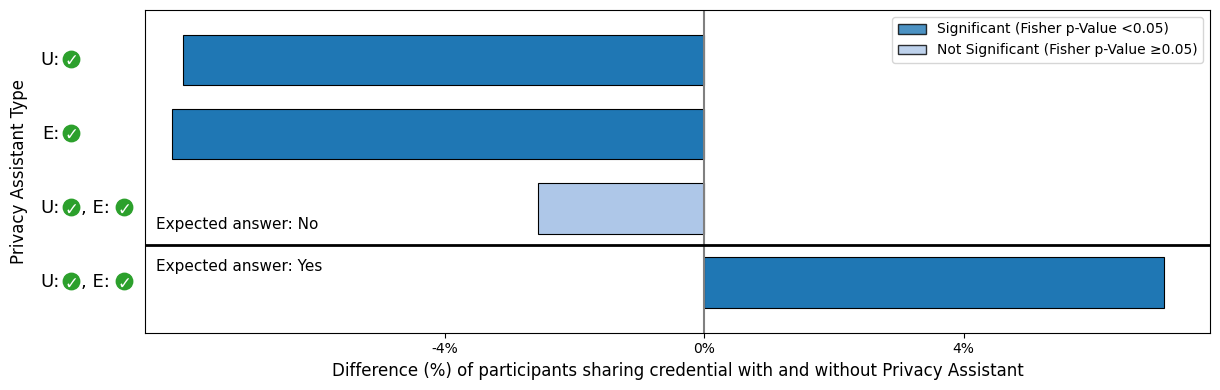

Saved: charts/user_study_mistakes_reduce.pdf


In [16]:
reduce_df = pd.read_csv('files/user_study_mistakes_reduce_table_fisher.csv')

reduce_df['Diff yes %'] = reduce_df['Diff yes %'].str.rstrip('%').astype(float)

reduce_df['Diff yes %'] = -reduce_df['Diff yes %']

reduce_df['label'] = reduce_df['Group'].str.replace(
    'and', 'and\n'
).str.replace(
    '(', '\n('
).str.strip()

# Significance flag
reduce_df['significant'] = reduce_df['p-Value (Fisher)'] < 0.05

reduce_df = reduce_df.iloc[::-1].reset_index(drop=True)

colors_reduce = ['#1f77b4' if sig else '#aec7e8' for sig in reduce_df['significant']]

height_reduce = max(4.0, 0.22 * len(reduce_df))
fig, ax = plt.subplots(figsize=(12, height_reduce))

y_step = 0.56
bar_height = 0.38
y_positions = [i * y_step for i in range(len(reduce_df))]

ax.barh(y_positions, reduce_df['Diff yes %'], color=colors_reduce, edgecolor='black', linewidth=0.8, height=bar_height)
ax.set_yticks(y_positions)
ax.set_yticklabels(reduce_df['label'])
ax.margins(y=0.002)
ax.set_ylim(-bar_height, y_positions[-1] + bar_height)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

# Add separator line between S5 and S6 (if present)
last_s5_index = None
first_s6_index = None
for i, label in enumerate(reduce_df['label']):
    if 'S5' in label:
        last_s5_index = i
    elif 'S6' in label and first_s6_index is None:
        first_s6_index = i

separator_y = None
if last_s5_index is not None and first_s6_index is not None:
    separator_y = (y_positions[last_s5_index] + y_positions[first_s6_index]) / 2
    ax.axhline(y=separator_y, color='black', linestyle='-', linewidth=2, zorder=10)

# Override y-axis labels for Privacy Assistant Type with custom green circle check icons
label_specs_top_to_bottom = [
    {'left': 'U:', 'right': None},
    {'left': 'E:', 'right': None},
    {'left': 'U:', 'right': 'E:'},
    {'left': 'U:', 'right': 'E:'}
]
label_specs = list(reversed(label_specs_top_to_bottom))
if len(reduce_df) == len(label_specs):
    ax.set_yticks(y_positions)
    ax.set_yticklabels([''] * len(y_positions))
    ax.tick_params(axis='y', length=0)
    ax.figure.subplots_adjust(left=0.24)
    ax.yaxis.set_label_coords(-0.11, 0.5)
    transform = ax.get_yaxis_transform()
    for y, spec in zip(y_positions, label_specs):
        ax.text(-0.08, y, spec['left'], transform=transform, ha='right', va='center', fontsize=13)
        ax.scatter(-0.07, y + 0.01, s=140, color='#2ca02c', transform=transform, clip_on=False, zorder=8)
        ax.text(-0.07, y, r'$\checkmark$', color='white', transform=transform, ha='center', va='center', fontsize=12, zorder=8)
        if spec['right'] is not None:
            ax.text(-0.06, y, ', ' + spec['right'], transform=transform, ha='left', va='center', fontsize=13)
            ax.scatter(-0.02, y + 0.01, s=140, color='#2ca02c', transform=transform, clip_on=False, zorder=8)
            ax.text(-0.02, y, r'$\checkmark$', color='white', transform=transform, ha='center', va='center', fontsize=12, zorder=8)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
max_abs_reduce = max(abs(reduce_df['Diff yes %'].min()), abs(reduce_df['Diff yes %'].max()))
tick_interval = 4
max_tick = int(max_abs_reduce / tick_interval) * tick_interval
ax.set_xticks([-max_tick + i * tick_interval for i in range(int(2 * max_tick / tick_interval) + 1) if -max_tick + i * tick_interval != 8 and -max_tick + i * tick_interval != -8])

ax.set_xlim(-max_abs_reduce * 1.05, max_abs_reduce * 0.95)

# Add annotations indicating expected answer above/below separator if present
if separator_y is not None:
    x_min, x_max = ax.get_xlim()
    ax.text(x_min * 0.98, separator_y + 0.1, 'Expected answer: No',
            ha='left', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), zorder=20)
    ax.text(x_min * 0.98, separator_y - 0.1, 'Expected answer: Yes',
            ha='left', va='top', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), zorder=20)

ax.set_xlabel('Difference (%) of participants sharing credential with and without Privacy Assistant', fontsize=12)
ax.set_ylabel('Privacy Assistant Type', fontsize=12)

legend_elements_reduce = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Fisher p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Fisher p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_reduce, fontsize=10, loc='best')

plt.tight_layout()

reduce_chart_path = 'charts/user_study_mistakes_reduce.pdf'
plt.savefig(reduce_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {reduce_chart_path}")

## Generate figures showing impact of confidence levels

Saved chart: charts\group_s1_confidence_levels.pdf


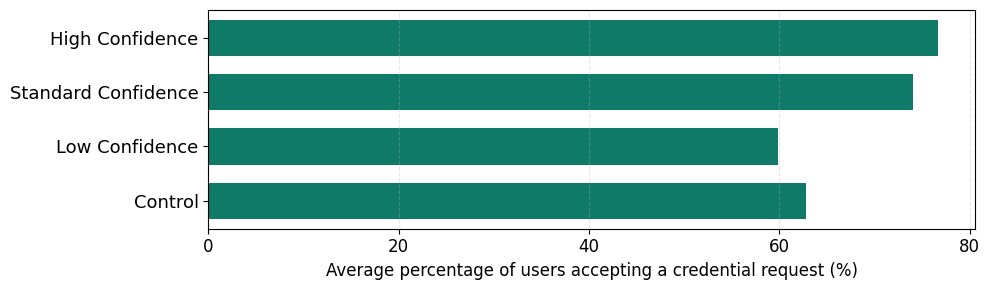

In [17]:
labels = ['Control', 'Low Confidence', 'Standard Confidence', 'High Confidence']
percentages = [62.76, 59.88, 74.05, 76.72]

fig, ax = plt.subplots(figsize=(10, 3))

y_positions = np.arange(len(labels)) * 0.3
bars = ax.barh(y_positions, percentages, color="#107A69", height=0.2)
ax.set_yticks(y_positions, labels)

max_val = max(percentages)
ax.set_xlim(0, max_val * 1.05)

ax.tick_params(axis='y', labelsize=13)

ax.set_xticks(np.arange(0, 100, 20))
ax.set_xticklabels([f'{int(x)}' for x in np.arange(0, 100, 20)], fontsize=12)
ax.set_xlabel("Average percentage of users accepting a credential request (%)", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

chart_path = OUTPUT_DIR / "group_s1_confidence_levels.pdf"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"Saved chart: {chart_path}")
plt.show()


## Generate charts showing expert disagreement on website categories and percentages per category

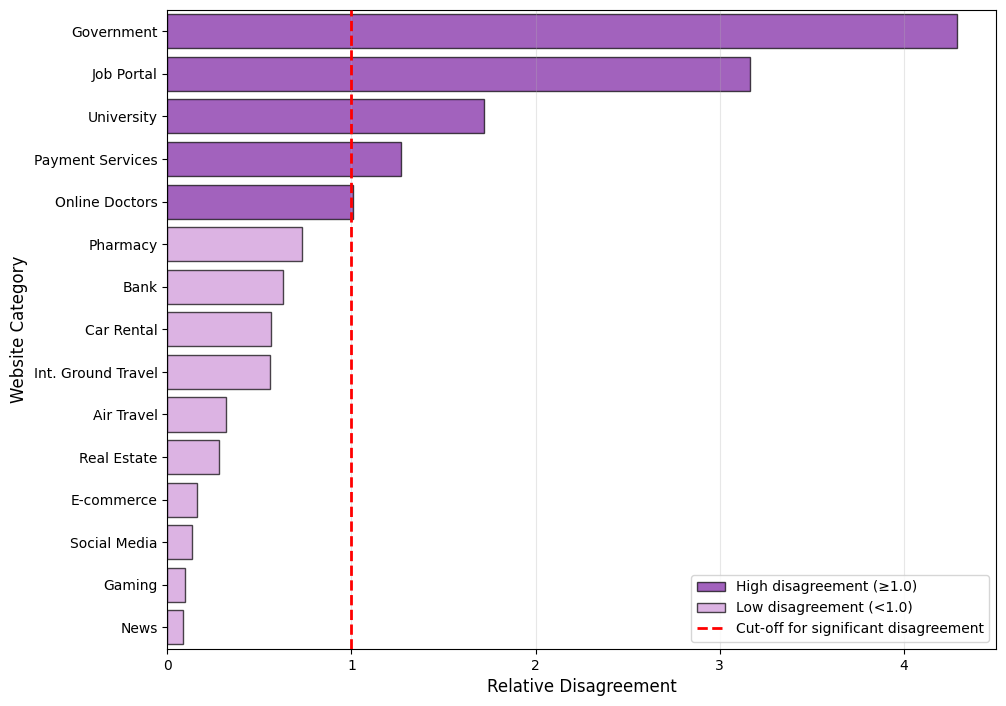

Saved chart to charts/expert_disagreement_by_category.pdf

Categories with above-average disagreement (≥1.0):
  Government: 4.29
  Job Portal: 3.16
  University: 1.72
  Payment Services: 1.27
  Online Doctors: 1.01


In [18]:
disagreement_df = pd.read_csv('tables/expert_disagreement_by_category.csv')

disagreement_df = disagreement_df.sort_values('relative_disagreement', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#7B1FA2' if x >= 1.0 else '#CE93D8' for x in disagreement_df['relative_disagreement']]
bars = ax.barh(disagreement_df['category'], disagreement_df['relative_disagreement'], 
        color=colors, alpha=0.7, edgecolor='black', linewidth=1)

ax.set_ylim(-0.5, len(disagreement_df) - 0.5)

ax.plot([1.0, 1.0], ax.get_ylim(), 
        color='red', linestyle='--', linewidth=2, zorder=10)

ax.set_xlabel('Relative Disagreement', fontsize=12)
ax.set_ylabel('Website Category', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#7B1FA2', edgecolor='black', alpha=0.7, label='High disagreement (≥1.0)'),
    Patch(facecolor='#CE93D8', edgecolor='black', alpha=0.7, label='Low disagreement (<1.0)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Cut-off for significant disagreement')
]

ax.grid(axis='x', alpha=0.3)
ax.legend(handles=legend_elements, fontsize=10)

fig.tight_layout(pad=0.5)

disagreement_chart_path = 'charts/expert_disagreement_by_category.pdf'
plt.savefig(disagreement_chart_path, dpi=200)
plt.show()

print(f"Saved chart to {disagreement_chart_path}")
print(f"\nCategories with above-average disagreement (≥1.0):")
above_avg = disagreement_df[disagreement_df['relative_disagreement'] >= 1.0].sort_values('relative_disagreement', ascending=False)
for _, row in above_avg.iterrows():
    print(f"  {row['category']}: {row['relative_disagreement']:.2f}")

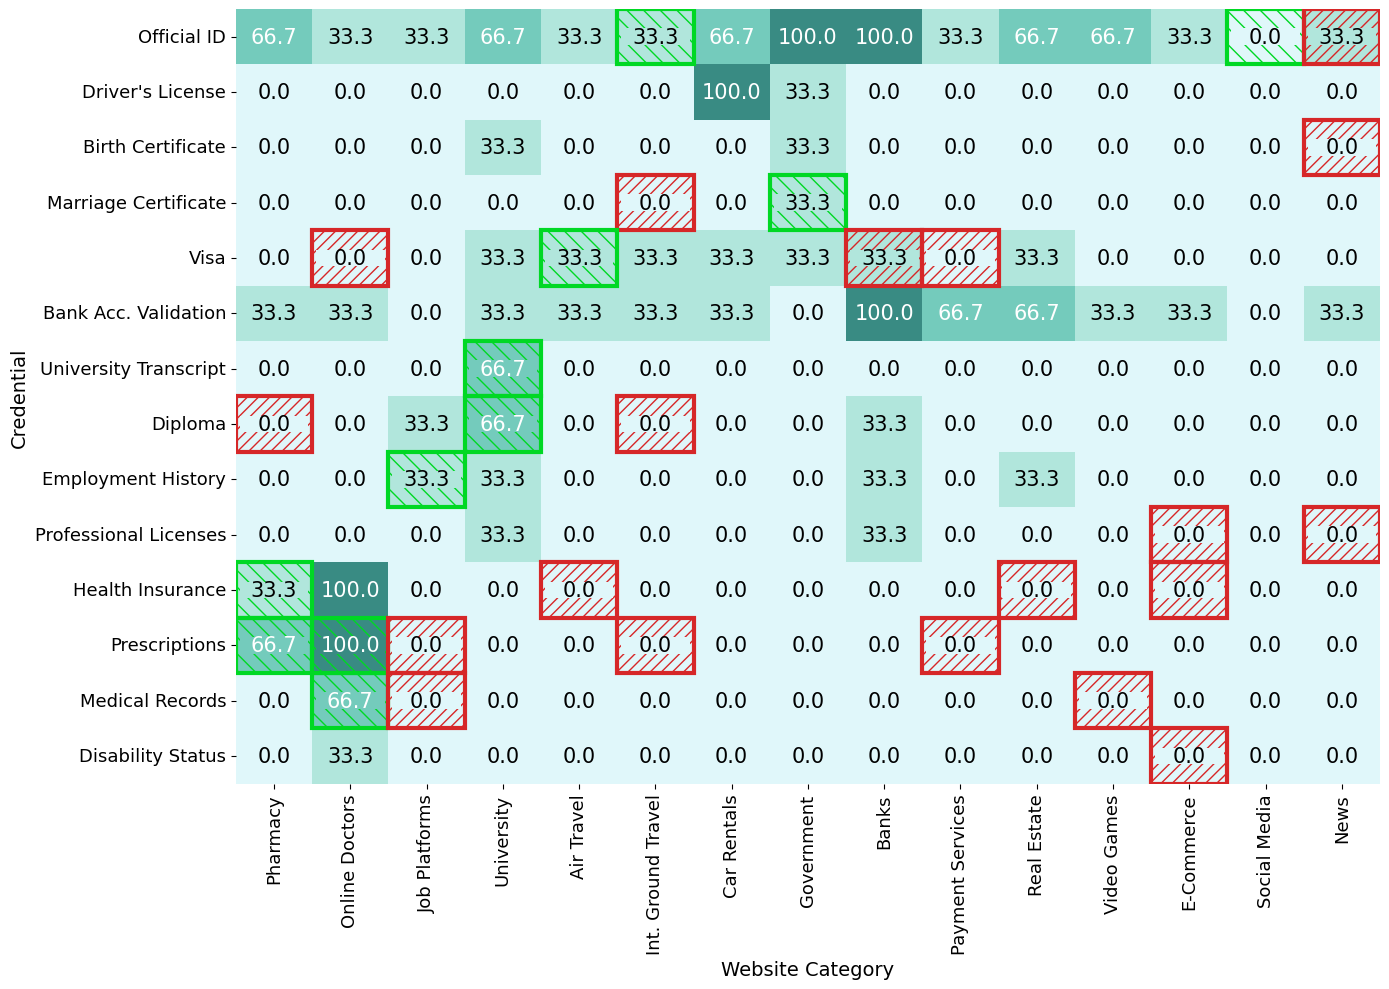

Saved: charts/expert_law_necessary_credentials_heatmap.pdf


In [19]:
#Law necessary heatmap

def normalize_credential(name: str) -> str:
    name = name.strip()
    name = name.replace('Official Id', 'Official ID')
    name = name.replace('Drivers License', "Driver's License")
    name = name.replace("Driver's License", "Driver's License")
    name = name.replace('Bank credentials', 'Bank Acc. Validation')
    name = name.replace('Bank Credentials', 'Bank Acc. Validation')
    name = name.title()
    name = name.replace(' Id', ' ID')
    name = name.replace('Official Id', 'Official ID')
    return name


def normalize_category(cat: str) -> str:
    cat = cat.strip()
    mapping = {
        'International Ground Travel': 'Int. Ground Travel',
        'Ground Travel': 'Int. Ground Travel',
        'Job Sites': 'Job Platforms',
        'Job Site': 'Job Platforms',
        'Job Portal': 'Job Platforms',
        'Payment': 'Payment Services',
        'E Commerce': 'E-Commerce',
        'E-Commerce': 'E-Commerce',
        'E commerce': 'E-Commerce',
        'Car Rentals': 'Car Rentals',
        'Car Rental': 'Car Rentals',
        'Health Services': 'Online Doctors',
        'Health Service': 'Online Doctors',
        'Bank': 'Banks',
        'Gaming': 'Video Games',
    }
    return mapping.get(cat, cat)

phase2_pairs_red = pd.read_csv('tables/user_study_no_justification.csv')
phase2_pairs_red['Category_norm'] = phase2_pairs_red['Category'].apply(normalize_category)
phase2_pairs_red['Credential_norm'] = phase2_pairs_red['Requested Credential'].apply(normalize_credential)
highlight_pairs_red = set(zip(phase2_pairs_red['Credential_norm'], phase2_pairs_red['Category_norm']))

phase2_pairs_green = pd.read_csv('tables/user_study_good_justification.csv')
phase2_pairs_green['Category_norm'] = phase2_pairs_green['Category'].apply(normalize_category)
phase2_pairs_green['Credential_norm'] = phase2_pairs_green['Requested Credential'].apply(normalize_credential)
highlight_pairs_green = set(zip(phase2_pairs_green['Credential_norm'], phase2_pairs_green['Category_norm']))

red_base = '#d62728'
green_base = "#00d824"


def lighten_color(color: str, amount: float = 0.45) -> str:
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return mcolors.to_hex((1 - amount) * c + amount * white)


def border_color(base: str, val: float, lighten: bool = False) -> str:
    return base

df = pd.read_csv('tables/expert_law_necessary_credentials.csv', index_col=0)

heatmap = df.copy()
for col in heatmap.columns:
    heatmap[col] = heatmap[col].str.rstrip('%').astype(float)

heatmap.rename(columns={
    'International Ground Travel': 'Int. Ground Travel',
    'Job Portal': 'Job Platforms',
    'Car Rental': 'Car Rentals',
    'Bank': 'Banks',
    'Gaming': 'Video Games',
    'E-commerce': 'E-Commerce',
}, inplace=True)

heatmap.rename(index={
    'Bank credentials': 'Bank Acc. Validation',
    'Official Identity Document': 'Official ID',
}, inplace=True)

heatmap.index = heatmap.index.str.title()
heatmap.rename(index={'Official Id': 'Official ID'}, inplace=True)
heatmap.rename(index={"Driver'S License": "Driver's License"}, inplace=True)

credential_order = [
    'Official ID', "Driver's License", 'Birth Certificate', 'Marriage Certificate', 'Visa',
    'Bank Acc. Validation', 'University Transcript', 'Diploma', 'Employment History',
    'Professional Licenses', 'Health Insurance', 'Prescriptions', 'Medical Records', 'Disability Status'
]

category_order = [
    'Pharmacy', 'Online Doctors', 'Job Platforms', 'University', 'Air Travel',
    'Int. Ground Travel', 'Car Rentals', 'Government', 'Banks', 'Payment Services',
    'Real Estate', 'Video Games', 'E-Commerce', 'Social Media', 'News'
]

heatmap = heatmap.reindex(credential_order)
heatmap = heatmap.reindex(columns=category_order)
heatmap.index = heatmap.index.astype(str)
heatmap.columns = heatmap.columns.astype(str)

fig, ax = plt.subplots(figsize=(14, 10))

teal_mix = LinearSegmentedColormap.from_list(
    'teal_mix',
    ['#e0f7fa', '#d2f3f0', '#c3eee7', '#b1e6dc', '#9fded2', '#8bd5c8', '#74cbbc', '#5db1a8', '#4aa395', '#398b83'],
    N=256
)

cmap = teal_mix
norm = plt.Normalize(vmin=0, vmax=100)

sns.heatmap(heatmap, annot=False, cmap=cmap, cbar=False, ax=ax, vmin=0, vmax=100)

# Hatched fills
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red:
            val = heatmap.iloc[i, j]
            hatch_color = border_color(red_base, val)
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=0, edgecolor=hatch_color,
                                   facecolor='none', hatch='///', zorder=4))
        if (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            hatch_color = border_color(green_base, val, lighten=True)
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=0, edgecolor=hatch_color,
                                   facecolor='none', hatch='\\\\', zorder=4))

# Add borders
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red:
            val = heatmap.iloc[i, j]
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=3,
                                   edgecolor=border_color(red_base, val), facecolor='none', zorder=5))
        if (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=3,
                                   edgecolor=border_color(green_base, val, lighten=True), facecolor='none', zorder=5))

# Clear a center band for text
cmap_obj = cmap
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red or (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            cell_color = cmap_obj(norm(val)) if pd.notna(val) else (1, 1, 1, 1)
            cx, cy = j + 0.5, i + 0.5
            clear_w, clear_h = 0.9, 0.30
            ax.add_patch(Rectangle((cx - clear_w/2, cy - clear_h/2), clear_w, clear_h,
                                   linewidth=0, facecolor=cell_color, alpha=1.0, zorder=5.5))

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        value = heatmap.iloc[i, j]
        if pd.isna(value):
            continue
        text_color = 'white' if value > 50 else 'black'
        ax.text(j + 0.5, i + 0.5, f'{value:.1f}', ha='center', va='center',
                color=text_color, fontsize=15, zorder=6)

ax.set_xlabel('Website Category', fontsize=14)
ax.set_ylabel('Credential', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
output_path = 'charts/expert_law_necessary_credentials_heatmap.pdf'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {output_path}")

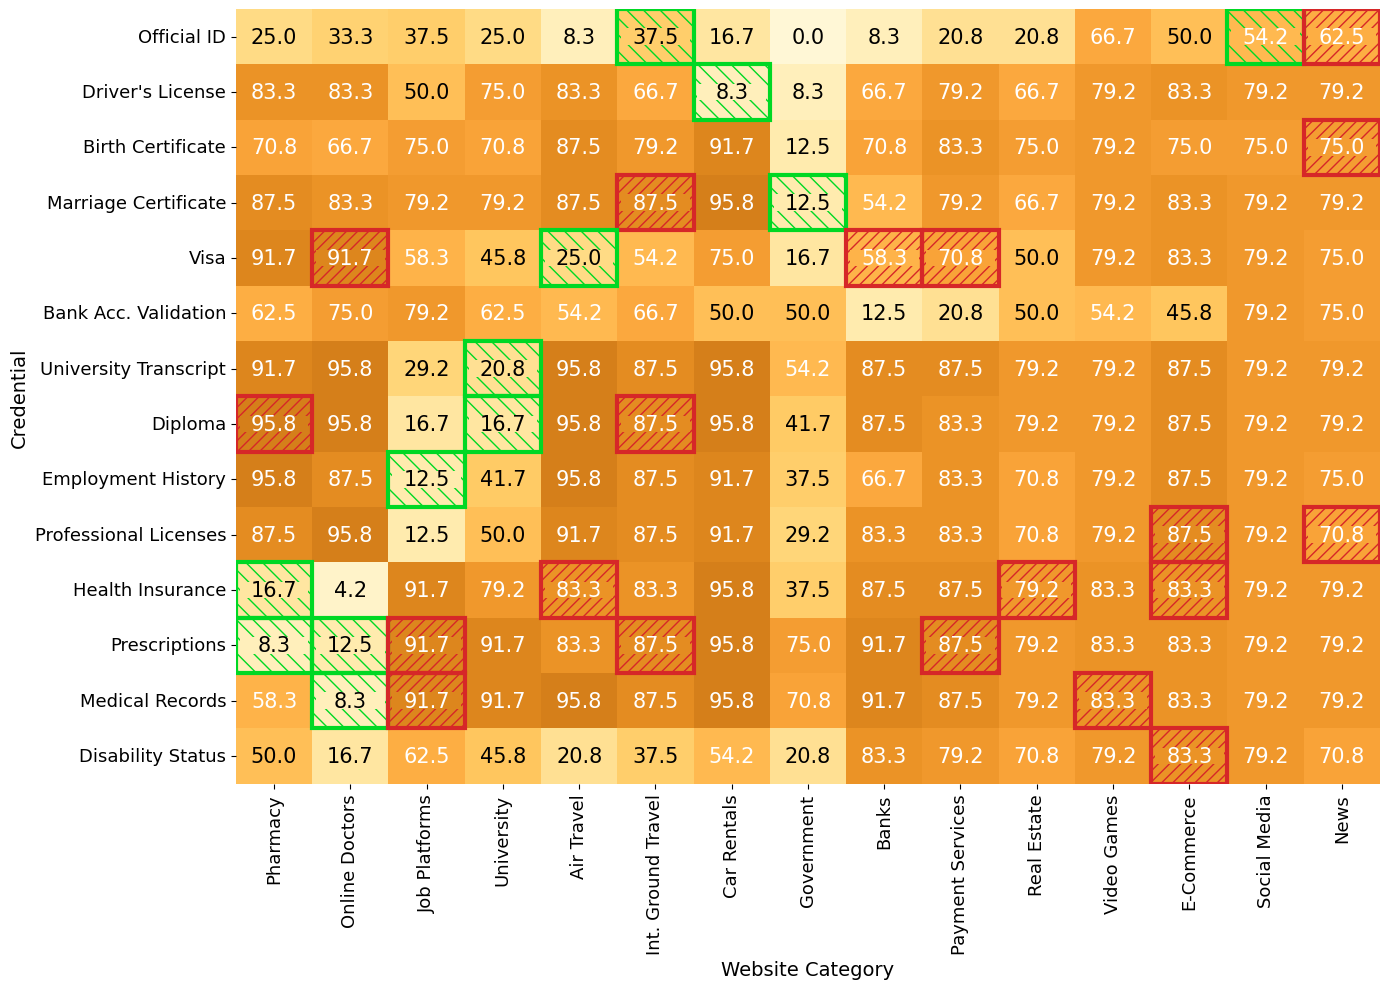

Saved: charts/expert_combined_never_credentials_heatmap.pdf


In [20]:
# Combined cybersecurity, policy, and ethics never share heatmap

def normalize_credential(name: str) -> str:
    name = name.strip()
    name = name.replace('Official Id', 'Official ID')
    name = name.replace('Drivers License', "Driver's License")
    name = name.replace('Driver’s License', "Driver's License")
    name = name.replace('Bank credentials', 'Bank Acc. Validation')
    name = name.replace('Bank Credentials', 'Bank Acc. Validation')
    name = name.title()
    name = name.replace(' Id', ' ID')
    name = name.replace('Official Id', 'Official ID')
    name = name.replace("Driver'S License", "Driver's License")
    return name

def normalize_category(cat: str) -> str:
    cat = cat.strip()
    mapping = {
        'International Ground Travel': 'Int. Ground Travel',
        'Ground Travel': 'Int. Ground Travel',
        'Job Sites': 'Job Platforms',
        'Job Site': 'Job Platforms',
        'Job Portal': 'Job Platforms',
        'Payment': 'Payment Services',
        'E Commerce': 'E-Commerce',
        'E-Commerce': 'E-Commerce',
        'E commerce': 'E-Commerce',
        'Car Rental': 'Car Rentals',
        'Car Rentals': 'Car Rentals',
        'Bank': 'Banks',
        'Banks': 'Banks',
        'Gaming': 'Video Games',
        'Video Games': 'Video Games',
        'Health Services': 'Online Doctors',
        'Health Service': 'Online Doctors',
    }
    return mapping.get(cat, cat)

phase2_pairs_red = pd.read_csv('tables/user_study_no_justification.csv')
phase2_pairs_red['Category_norm'] = phase2_pairs_red['Category'].apply(normalize_category)
phase2_pairs_red['Credential_norm'] = phase2_pairs_red['Requested Credential'].apply(normalize_credential)
highlight_pairs_red = set(zip(phase2_pairs_red['Credential_norm'], phase2_pairs_red['Category_norm']))

phase2_pairs_green = pd.read_csv('tables/user_study_good_justification.csv')
phase2_pairs_green['Category_norm'] = phase2_pairs_green['Category'].apply(normalize_category)
phase2_pairs_green['Credential_norm'] = phase2_pairs_green['Requested Credential'].apply(normalize_credential)
highlight_pairs_green = set(zip(phase2_pairs_green['Credential_norm'], phase2_pairs_green['Category_norm']))

credential_order = [
    'Official ID', "Driver's License", 'Birth Certificate', 'Marriage Certificate', 'Visa',
    'Bank Acc. Validation', 'University Transcript', 'Diploma', 'Employment History',
    'Professional Licenses', 'Health Insurance', 'Prescriptions', 'Medical Records', 'Disability Status'
 ]

category_order = [
    'Pharmacy', 'Online Doctors', 'Job Platforms', 'University', 'Air Travel',
    'Int. Ground Travel', 'Car Rentals', 'Government', 'Banks', 'Payment Services',
    'Real Estate', 'Video Games', 'E-Commerce', 'Social Media', 'News'
 ]

red_base = '#d62728'
green_base = '#00d824'

def mix_with_white(color: str, amount: float = 0.12) -> str:
    amount = max(0.0, min(1.0, amount))
    rgb = np.array(mcolors.to_rgb(color))
    mixed = 1 - (1 - rgb) * (1 - amount)
    return mcolors.to_hex(mixed)

def border_color(base: str, cell_val: float, cmap, norm, threshold: float = 0.38) -> str:
    if pd.isna(cell_val):
        return base
    r, g, b, _ = cmap(norm(cell_val))
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    if base == red_base and luminance < threshold:
        return mix_with_white(base, amount=0.12)
    return base

yellow_orange = LinearSegmentedColormap.from_list(
    'yellow_orange',
    ['#fff7d6', '#ffe9a8', '#ffd67a', '#ffca63', '#ffb54b', '#f9a237', '#e89023', '#ce7816'],
    N=256
)

df = pd.read_csv('tables/expert_combined_never_credentials.csv', index_col=0)
heatmap = df.copy()
for col in heatmap.columns:
    heatmap[col] = heatmap[col].str.rstrip('%').astype(float)

heatmap.rename(columns={'International Ground Travel': 'Int. Ground Travel'}, inplace=True)
heatmap.rename(columns={'Job Portal': 'Job Platforms'}, inplace=True)
heatmap.rename(columns={'Car Rental': 'Car Rentals'}, inplace=True)
heatmap.rename(columns={'Bank': 'Banks'}, inplace=True)
heatmap.rename(columns={'Gaming': 'Video Games'}, inplace=True)
heatmap.rename(columns={'E-commerce': 'E-Commerce'}, inplace=True)

heatmap.rename(index={'Bank credentials': 'Bank Acc. Validation', 'Bank Credentials': 'Bank Acc. Validation'}, inplace=True)
heatmap.rename(index={'Official Identity Document': 'Official ID'}, inplace=True)

heatmap.index = heatmap.index.str.title()
heatmap.rename(index={'Official Id': 'Official ID'}, inplace=True)
heatmap.rename(index={"Driver'S License": "Driver's License"}, inplace=True)

heatmap = heatmap.reindex(credential_order)
heatmap = heatmap.reindex(columns=category_order)
heatmap.index = heatmap.index.astype(str)
heatmap.columns = heatmap.columns.astype(str)

fig, ax = plt.subplots(figsize=(14, 10))
cmap = yellow_orange
norm = plt.Normalize(vmin=0, vmax=100)

sns.heatmap(heatmap, annot=False, cmap=cmap, cbar=False, ax=ax, vmin=0, vmax=100)

# Hatching
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        cell_val = heatmap.iloc[i, j]
        if (cred, cat) in highlight_pairs_red:
            hatch_color = border_color(red_base, cell_val, cmap, norm)
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=0, edgecolor=hatch_color,
                                   facecolor='none', hatch='///', zorder=4))
        if (cred, cat) in highlight_pairs_green:
            hatch_color = border_color(green_base, cell_val, cmap, norm)
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=0, edgecolor=hatch_color,
                                   facecolor='none', hatch='\\\\', zorder=4))

# Borders
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        cell_val = heatmap.iloc[i, j]
        if (cred, cat) in highlight_pairs_red:
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=3,
                                   edgecolor=border_color(red_base, cell_val, cmap, norm), facecolor='none', zorder=5))
        if (cred, cat) in highlight_pairs_green:
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=3,
                                   edgecolor=border_color(green_base, cell_val, cmap, norm), facecolor='none', zorder=5))

# Clear band behind text
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red or (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            cell_color = cmap(norm(val)) if pd.notna(val) else (1, 1, 1, 1)
            cx, cy = j + 0.5, i + 0.5
            clear_w, clear_h = 0.9, 0.30
            ax.add_patch(Rectangle((cx - clear_w/2, cy - clear_h/2), clear_w, clear_h,
                                   linewidth=0, facecolor=cell_color, alpha=1.0, zorder=5.5))

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        value = heatmap.iloc[i, j]
        if pd.isna(value):
            continue
        text_color = 'white' if value > 50 else 'black'
        ax.text(j + 0.5, i + 0.5, f'{value:.1f}', ha='center', va='center',
                color=text_color, fontsize=15, zorder=6)

ax.set_xlabel('Website Category', fontsize=14)
ax.set_ylabel('Credential', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
output_path = 'charts/expert_combined_never_credentials_heatmap.pdf'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")

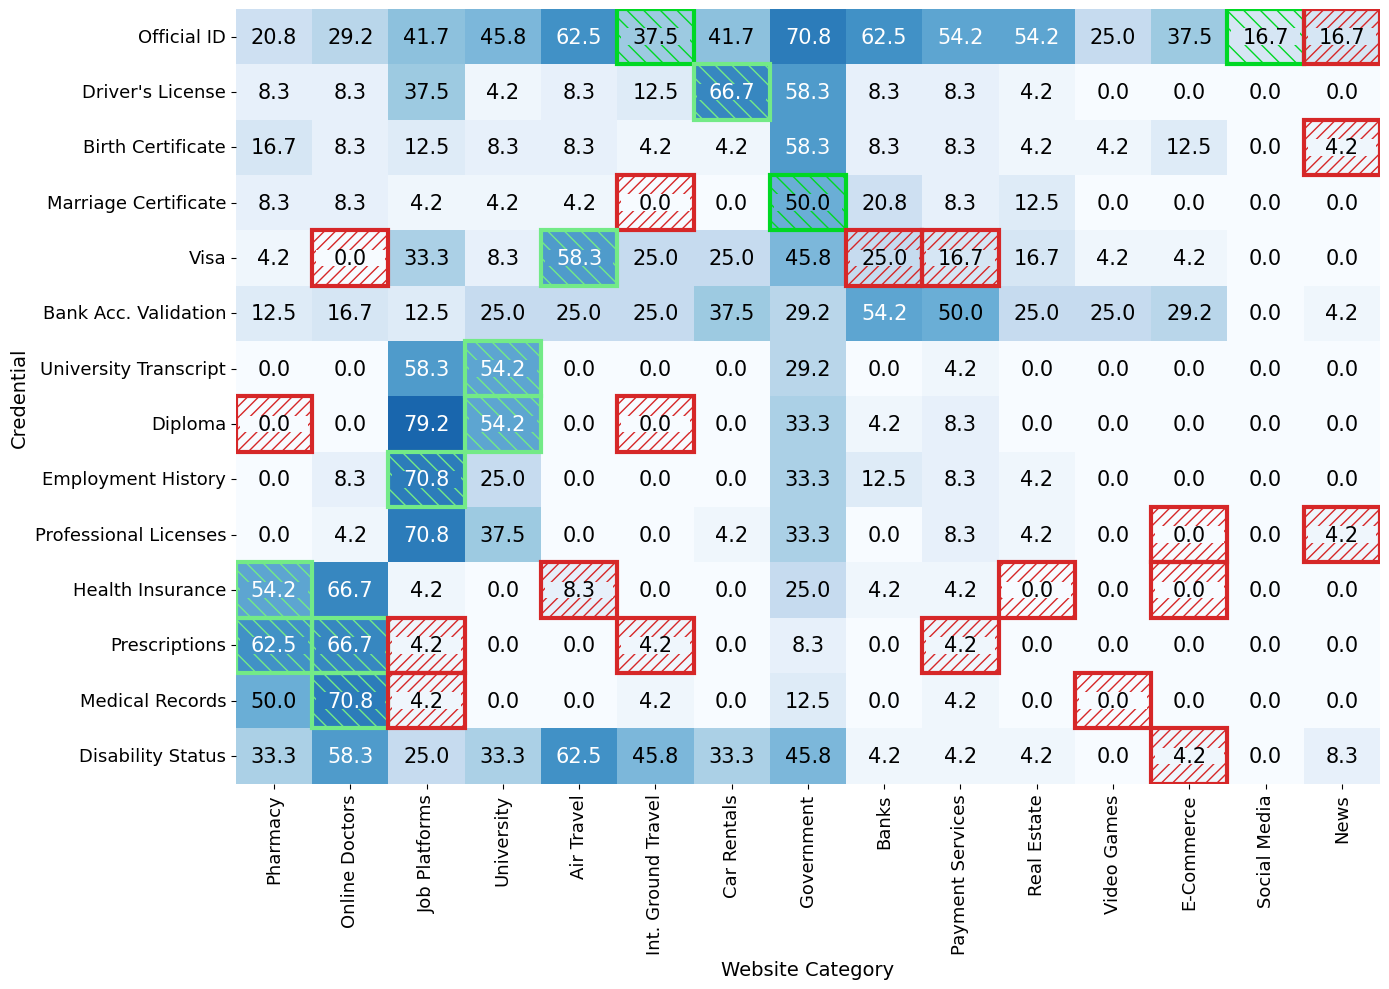

Saved: charts/expert_combined_permissible_credentials_heatmap.pdf


In [21]:
# Combined cybersecurity, policy, and ethics permissible credentials heatmap 

def normalize_credential(name: str) -> str:
    name = name.strip()
    name = name.replace('Official Id', 'Official ID')
    name = name.replace('Drivers License', "Driver's License")
    name = name.replace('Driver’s License', "Driver's License")
    name = name.replace('Bank credentials', 'Bank Acc. Validation')
    name = name.replace('Bank Credentials', 'Bank Acc. Validation')
    name = name.title()
    name = name.replace(' Id', ' ID')
    name = name.replace('Official Id', 'Official ID')
    name = name.replace("Driver'S License", "Driver's License")
    return name

def normalize_category(cat: str) -> str:
    cat = cat.strip()
    mapping = {
        'International Ground Travel': 'Int. Ground Travel',
        'Ground Travel': 'Int. Ground Travel',
        'Job Sites': 'Job Platforms',
        'Job Site': 'Job Platforms',
        'Job Portal': 'Job Platforms',
        'Payment': 'Payment Services',
        'E Commerce': 'E-Commerce',
        'E-Commerce': 'E-Commerce',
        'E commerce': 'E-Commerce',
        'Car Rental': 'Car Rentals',
        'Car Rentals': 'Car Rentals',
        'Bank': 'Banks',
        'Banks': 'Banks',
        'Gaming': 'Video Games',
        'Video Games': 'Video Games',
        'Health Services': 'Online Doctors',
        'Health Service': 'Online Doctors',
    }
    return mapping.get(cat, cat)

phase2_pairs_red = pd.read_csv('tables/user_study_no_justification.csv')
phase2_pairs_red['Category_norm'] = phase2_pairs_red['Category'].apply(normalize_category)
phase2_pairs_red['Credential_norm'] = phase2_pairs_red['Requested Credential'].apply(normalize_credential)
highlight_pairs_red = set(zip(phase2_pairs_red['Credential_norm'], phase2_pairs_red['Category_norm']))

phase2_pairs_green = pd.read_csv('tables/user_study_good_justification.csv')
phase2_pairs_green['Category_norm'] = phase2_pairs_green['Category'].apply(normalize_category)
phase2_pairs_green['Credential_norm'] = phase2_pairs_green['Requested Credential'].apply(normalize_credential)
highlight_pairs_green = set(zip(phase2_pairs_green['Credential_norm'], phase2_pairs_green['Category_norm']))

credential_order = [
    'Official ID', "Driver's License", 'Birth Certificate', 'Marriage Certificate', 'Visa',
    'Bank Acc. Validation', 'University Transcript', 'Diploma', 'Employment History',
    'Professional Licenses', 'Health Insurance', 'Prescriptions', 'Medical Records', 'Disability Status'
 ]

category_order = [
    'Pharmacy', 'Online Doctors', 'Job Platforms', 'University', 'Air Travel',
    'Int. Ground Travel', 'Car Rentals', 'Government', 'Banks', 'Payment Services',
    'Real Estate', 'Video Games', 'E-Commerce', 'Social Media', 'News'
 ]

red_base = '#d62728'
green_base = '#00d824'

def lighten_color(color: str, amount: float = 0.4) -> str:
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return mcolors.to_hex((1 - amount) * c + amount * white)

def border_color(base: str, val: float, lighten: bool = False) -> str:
    if pd.notna(val) and val > 50:
        if lighten:
            return lighten_color(base, amount=0.45)
        return 'white'
    return base

df = pd.read_csv('tables/expert_combined_permissible_credentials.csv', index_col=0)
heatmap = df.copy()
for col in heatmap.columns:
    heatmap[col] = heatmap[col].str.rstrip('%').astype(float)

heatmap.rename(columns={'International Ground Travel': 'Int. Ground Travel'}, inplace=True)
heatmap.rename(columns={'Job Portal': 'Job Platforms'}, inplace=True)
heatmap.rename(columns={'Car Rental': 'Car Rentals'}, inplace=True)
heatmap.rename(columns={'Bank': 'Banks'}, inplace=True)
heatmap.rename(columns={'Gaming': 'Video Games'}, inplace=True)
heatmap.rename(columns={'E-commerce': 'E-Commerce'}, inplace=True)

heatmap.rename(index={'Bank credentials': 'Bank Acc. Validation', 'Bank Credentials': 'Bank Acc. Validation'}, inplace=True)
heatmap.rename(index={'Official Identity Document': 'Official ID'}, inplace=True)

heatmap.index = heatmap.index.str.title()
heatmap.rename(index={'Official Id': 'Official ID'}, inplace=True)
heatmap.rename(index={"Driver'S License": "Driver's License"}, inplace=True)

heatmap = heatmap.reindex(credential_order)
heatmap = heatmap.reindex(columns=category_order)
heatmap.index = heatmap.index.astype(str)
heatmap.columns = heatmap.columns.astype(str)

fig, ax = plt.subplots(figsize=(14, 10))
cmap = sns.color_palette('Blues', as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=100)

sns.heatmap(heatmap, annot=False, cmap=cmap, cbar=False, ax=ax, vmin=0, vmax=100)

# Hatched fills
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red:
            val = heatmap.iloc[i, j]
            hatch_color = border_color(red_base, val)
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=0, edgecolor=hatch_color,
                                   facecolor='none', hatch='///', zorder=4))
        if (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            hatch_color = border_color(green_base, val, lighten=True)
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=0, edgecolor=hatch_color,
                                   facecolor='none', hatch='\\\\', zorder=4))

# Borders
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red:
            val = heatmap.iloc[i, j]
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=3,
                                   edgecolor=border_color(red_base, val), facecolor='none', zorder=5))
        if (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            ax.add_patch(Rectangle((j, i), 1, 1, linewidth=3,
                                   edgecolor=border_color(green_base, val, lighten=True), facecolor='none', zorder=5))

# Clear band behind text
for i, cred in enumerate(heatmap.index):
    for j, cat in enumerate(heatmap.columns):
        if (cred, cat) in highlight_pairs_red or (cred, cat) in highlight_pairs_green:
            val = heatmap.iloc[i, j]
            cell_color = cmap(norm(val)) if pd.notna(val) else (1, 1, 1, 1)
            cx, cy = j + 0.5, i + 0.5
            clear_w, clear_h = 0.9, 0.30
            ax.add_patch(Rectangle((cx - clear_w/2, cy - clear_h/2), clear_w, clear_h,
                                   linewidth=0, facecolor=cell_color, alpha=1.0, zorder=5.5))

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        value = heatmap.iloc[i, j]
        if pd.isna(value):
            continue
        text_color = 'white' if value > 50 else 'black'
        ax.text(j + 0.5, i + 0.5, f'{value:.1f}', ha='center', va='center',
                color=text_color, fontsize=15, zorder=6)

ax.set_xlabel('Website Category', fontsize=14)
ax.set_ylabel('Credential', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
output_path = 'charts/expert_combined_permissible_credentials_heatmap.pdf'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")

In [22]:
# Scatter plot for expert choice never vs. permissible
never_df = pd.read_csv('tables/expert_combined_never_credentials.csv', index_col=0)
permissible_df = pd.read_csv('tables/expert_combined_permissible_credentials.csv', index_col=0)
necessary_df = pd.read_csv('tables/expert_law_necessary_credentials.csv', index_col=0)
justifications_df = pd.read_csv('files/justifications.csv', index_col=0)

column_mapping = {
    'Int. Ground Travel': 'International Ground Travel'
}

plot_data = []

for credential in never_df.index:
    for website in never_df.columns:
        never_pct = float(never_df.loc[credential, website].strip('%')) if isinstance(never_df.loc[credential, website], str) else never_df.loc[credential, website]
        permissible_pct = float(permissible_df.loc[credential, website].strip('%')) if isinstance(permissible_df.loc[credential, website], str) else permissible_df.loc[credential, website]
        
        justification = justifications_df.loc[credential, website]
        
        necessary_count = 0
        
        website_for_necessary = column_mapping.get(website, website)
        
        if website_for_necessary in necessary_df.columns:
            for nec_credential in necessary_df.index:
                if nec_credential.lower() in credential.lower() or credential.lower() in nec_credential.lower():
                    nec_val = necessary_df.loc[nec_credential, website_for_necessary]
                    if isinstance(nec_val, str):
                        necessary_count = int(float(nec_val.strip('%'))) // 33  # Convert percentage to count (0-3)
                    else:
                        necessary_count = int(nec_val) // 33
                    break
        
        plot_data.append({
            'credential': credential,
            'website': website,
            'never_pct': never_pct,
            'permissible_pct': permissible_pct,
            'justification': justification,
            'necessary_count': necessary_count,
            'pair': f"{credential} × {website}"
        })

plot_df = pd.DataFrame(plot_data)

print("Plot data prepared:")
print(f"Total points: {len(plot_df)}")
print(f"Sample rows:")
print(plot_df.head())
print(f"\nJustification categories: {plot_df['justification'].unique()}")
print(f"Necessary count range: {plot_df['necessary_count'].min()} to {plot_df['necessary_count'].max()}")


Plot data prepared:
Total points: 210
Sample rows:
    credential         website  never_pct  permissible_pct  justification  \
0  Official ID        Pharmacy      25.00            20.84              1   
1  Official ID  Online Doctors      33.33            29.16              0   
2  Official ID      Government       0.00            70.83              1   
3  Official ID      Job Portal      37.50            41.67              1   
4  Official ID      University      25.00            45.83              1   

   necessary_count                          pair  
0                2        Official ID × Pharmacy  
1                1  Official ID × Online Doctors  
2                3      Official ID × Government  
3                1      Official ID × Job Portal  
4                2      Official ID × University  

Justification categories: [ 1  0 -1]
Necessary count range: 0 to 3


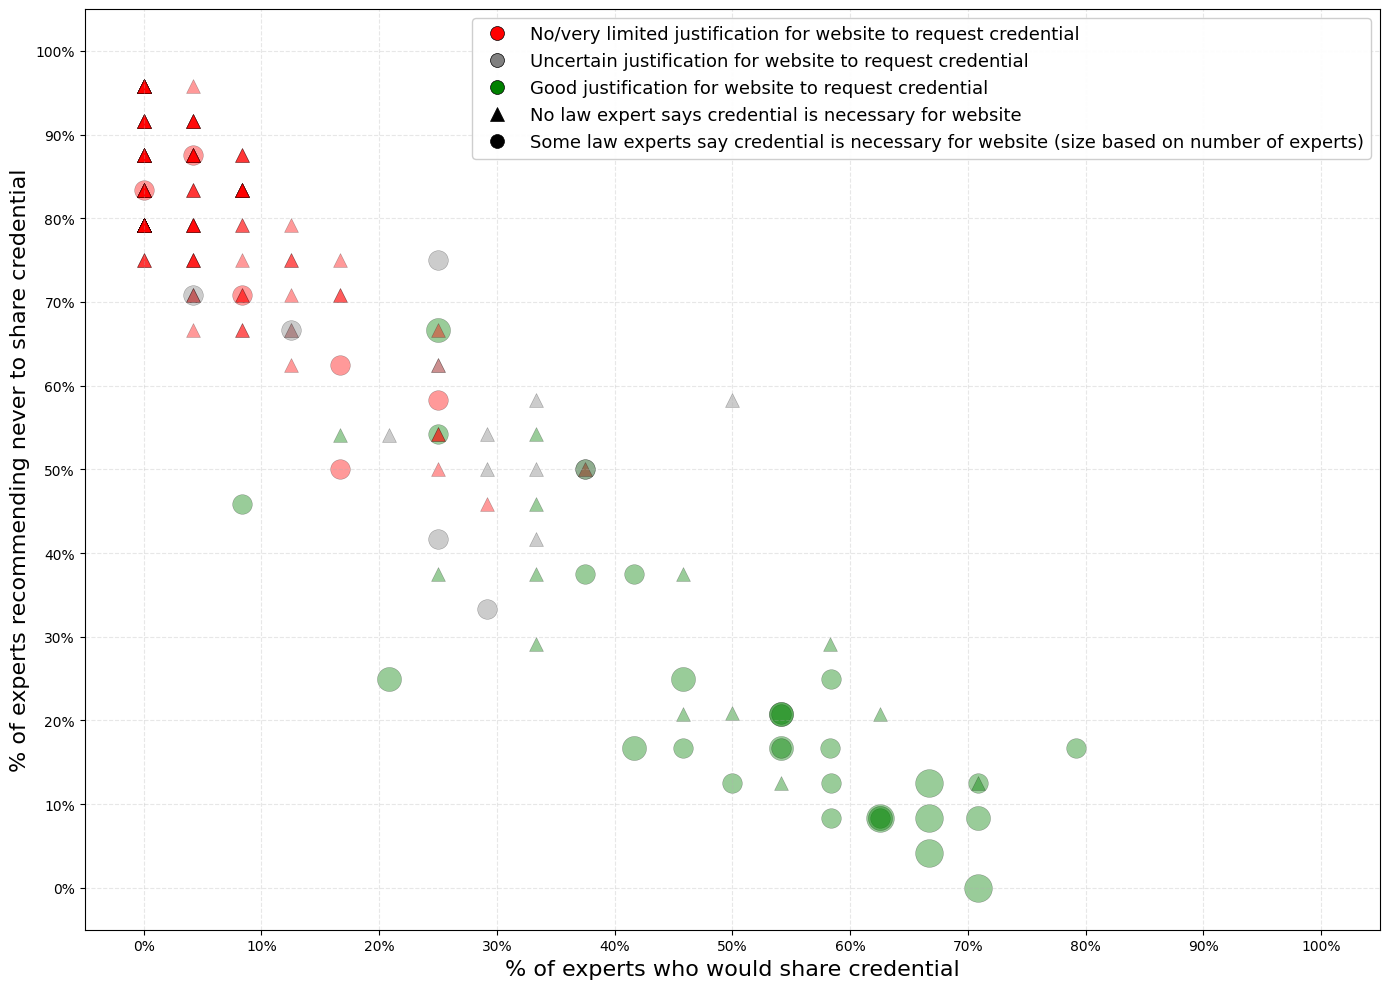

Saved scatter plot: charts/credential_alignment_vs_conflict.pdf


In [23]:
fig, ax = plt.subplots(figsize=(14, 10))

color_map = {-1: 'red', 0: 'gray', 1: 'green'}
marker_map = {0: '^', 1: 'o'}  # 0 = no law expert says necessary (triangle), 1 = otherwise (circle)

# Size normalization for necessary_count
size_scale = 100  # Base size multiplier

for idx, row in plot_df.iterrows():
    justification = row['justification']
    necessary_count = row['necessary_count']
    
    # Determine marker shape: triangle if no law expert says "necessary" (count=0), circle otherwise
    marker = '^' if necessary_count == 0 else 'o'
    
    # Determine color based on justification
    color = color_map[justification]
    
    # Size based on necessary_count (0-3), scaled appropriately
    size = (necessary_count + 1) * size_scale  # +1 to ensure all points are visible
    
    ax.scatter(
        row['permissible_pct'],
        row['never_pct'],
        s=size,
        c=color,
        marker=marker,
        alpha=0.4,  
        edgecolors='black',
        linewidth=0.3,
        label=None
    )

ax.set_xlabel('% of experts who would share credential', fontsize=16)
ax.set_ylabel('% of experts recommending never to share credential', fontsize=16)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)

ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_locator(plt.MultipleLocator(10))

ax.grid(True, alpha=0.3, linestyle='--')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, 
           label='No/very limited justification for website to request credential', 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           label='Uncertain justification for website to request credential', 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, 
           label='Good justification for website to request credential', 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=10, 
           label='No law expert says credential is necessary for website', 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, 
           label='Some law experts say credential is necessary for website (size based on number of experts)', 
           markeredgecolor='black', markeredgewidth=0.5),
]

ax.legend(handles=legend_elements, fontsize=13, loc='upper right', framealpha=0.95)

plt.tight_layout()

scatter_chart_path = 'charts/credential_alignment_vs_conflict.pdf'
plt.savefig(scatter_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved scatter plot: {scatter_chart_path}")


C:\Users\zingg\AppData\Local\Temp\ipykernel_35792\3207126039.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  never_df = never_df.applymap(parse_percentage)
C:\Users\zingg\AppData\Local\Temp\ipykernel_35792\3207126039.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  permissible_df = permissible_df.applymap(parse_percentage)


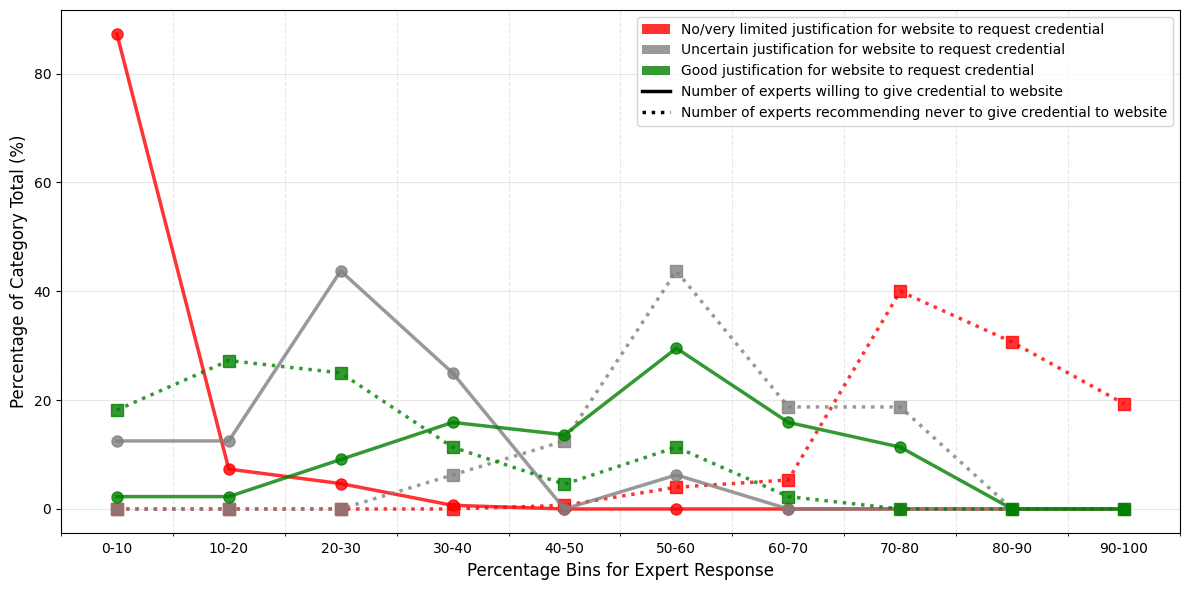

Saved combined line chart: charts/credential_expert_bins_line_chart_combined.pdf


In [24]:
# Line plot for expert choice never vs. permissible
never_df = pd.read_csv('tables/expert_combined_never_credentials.csv', index_col=0)
permissible_df = pd.read_csv('tables/expert_combined_permissible_credentials.csv', index_col=0)
justifications_df = pd.read_csv('files/justifications.csv', index_col=0)

def parse_percentage(val):
    if isinstance(val, str):
        return float(val.rstrip('%')) / 100
    return val / 100

never_df = never_df.applymap(parse_percentage)
permissible_df = permissible_df.applymap(parse_percentage)

# Define expert percentage bins (0-10, 10-20, ..., 90-100)
bins = np.arange(0, 101, 10)
bin_labels = [f"{i}-{i+10}" for i in range(0, 91, 10)]

chart_data = {
    -1: {label: {'Would give': 0, 'Say never': 0} for label in bin_labels},
    0: {label: {'Would give': 0, 'Say never': 0} for label in bin_labels},
    1: {label: {'Would give': 0, 'Say never': 0} for label in bin_labels}
}

for credential in never_df.index:
    for website in never_df.columns:
        try:
            never_pct = never_df.loc[credential, website] * 100  
            permissible_pct = permissible_df.loc[credential, website] * 100  
            justification = justifications_df.loc[credential, website]
            
            # Determine which bin each percentage falls into
            never_bin_idx = int(np.clip(never_pct // 10, 0, 9))
            never_bin = bin_labels[never_bin_idx]
            
            permissible_bin_idx = int(np.clip(permissible_pct // 10, 0, 9))
            permissible_bin = bin_labels[permissible_bin_idx]
            
            # Count the pairs in both bins
            chart_data[justification][never_bin]['Say never'] += 1
            chart_data[justification][permissible_bin]['Would give'] += 1
            
        except (KeyError, ValueError, TypeError):
            continue

fig, ax = plt.subplots(figsize=(12, 6))

justification_names = {-1: 'No/Limited Justification', 0: 'Uncertain Justification', 1: 'Good Justification'}
colors = {-1: 'red', 0: 'gray', 1: 'green'}

category_totals = {}
for just_cat in [-1, 0, 1]:
    total_would_give = sum(chart_data[just_cat][b]['Would give'] for b in bin_labels)
    total_say_never = sum(chart_data[just_cat][b]['Say never'] for b in bin_labels)
    category_totals[just_cat] = {'Would give': total_would_give, 'Say never': total_say_never}

x_positions = np.arange(len(bin_labels)) + 0.5 
lines_data = []

for just_cat in [-1, 0, 1]:
    would_give_counts = [chart_data[just_cat][bin_label]['Would give'] for bin_label in bin_labels]
    would_give_total = category_totals[just_cat]['Would give']
    would_give_percentages = [(count / would_give_total * 100) if would_give_total > 0 else 0 for count in would_give_counts]
    
    ax.plot(x_positions, would_give_percentages, marker='o', linestyle='-', linewidth=2.5, 
            markersize=8, label=f'{justification_names[just_cat]} - Would give', 
            color=colors[just_cat], alpha=0.8)
    
    say_never_counts = [chart_data[just_cat][bin_label]['Say never'] for bin_label in bin_labels]
    say_never_total = category_totals[just_cat]['Say never']
    say_never_percentages = [(count / say_never_total * 100) if say_never_total > 0 else 0 for count in say_never_counts]
    
    ax.plot(x_positions, say_never_percentages, marker='s', linestyle=':', linewidth=2.5, 
            markersize=8, label=f'{justification_names[just_cat]} - Say never', 
            color=colors[just_cat], alpha=0.8)

ax.set_xlabel('Percentage Bins for Expert Response', fontsize=12)
ax.set_ylabel('Percentage of Category Total (%)', fontsize=12)

ax.set_xticks(np.arange(0, len(bin_labels) + 1))
ax.set_xticks(x_positions, minor=False)
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
ax.tick_params(bottom=False)
ax.set_xticks(np.arange(0, len(bin_labels) + 1), minor=True)

ax.grid(True, which='minor', alpha=0.3, linestyle='--', axis='x')
ax.grid(True, which='major', alpha=0.3, linestyle='-', axis='y')

legend_elements = [
    Patch(facecolor='red', alpha=0.8, label='No/very limited justification for website to request credential'),
    Patch(facecolor='gray', alpha=0.8, label='Uncertain justification for website to request credential'),
    Patch(facecolor='green', alpha=0.8, label='Good justification for website to request credential'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='-', label='Number of experts willing to give credential to website'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle=':', label='Number of experts recommending never to give credential to website'),
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()

line_chart_path = 'charts/credential_expert_bins_line_chart_combined.pdf'
plt.savefig(line_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved combined line chart: {line_chart_path}")

## Generate figures for the website provided purpose comparison

Data read from file: [9.8, 11.9, 9.35, 21.82, 9.38, 16.0]
Chart saved to charts/s2_purpose_credential_chart.pdf


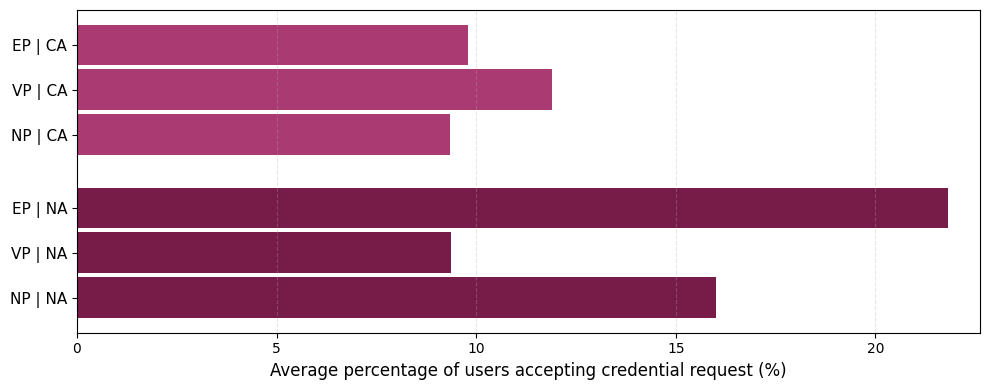

In [25]:
# Chart for cases without justification for the website to request the credential; i.e., purposes are fully fictional

with open('data/user_study_results_agg.txt', 'r') as f:
    content = f.read()

s2_match = re.search(r'=== Group S2 ===(.*?)=== Group S3 ===', content, re.DOTALL)
if s2_match:
    s2_content = s2_match.group(1)
    
    np_ca_match = re.search(r'Overall Aggregated.*?Yes: \d+ \(([0-9.]+)%\)', s2_content, re.DOTALL)
    np_ca = float(np_ca_match.group(1)) if np_ca_match else 9.35
    
    np_na_match = re.search(r'CONTROL scenarios:.*?Aggregated for: s2_all_good.*?Yes: \d+ \(([0-9.]+)%\)', s2_content, re.DOTALL)
    np_na = float(np_na_match.group(1)) if np_na_match else 16.00
    
    vp_na_match = re.search(r'CONTROL scenarios:.*?Aggregated for: s2_vague.*?Yes: \d+ \(([0-9.]+)%\)', s2_content, re.DOTALL)
    vp_na = float(vp_na_match.group(1)) if vp_na_match else 9.38
    
    ep_na_match = re.search(r'CONTROL scenarios:.*?Aggregated for: s2_bogus.*?Yes: \d+ \(([0-9.]+)%\)', s2_content, re.DOTALL)
    ep_na = float(ep_na_match.group(1)) if ep_na_match else 21.82
    
    vp_ca_match = re.search(r'TEST scenarios:.*?Aggregated for: s2_vague.*?Yes: \d+ \(([0-9.]+)%\)', s2_content, re.DOTALL)
    vp_ca = float(vp_ca_match.group(1)) if vp_ca_match else 11.90
    
    ep_ca_match = re.search(r'TEST scenarios:.*?Aggregated for: s2_bogus.*?Yes: \d+ \(([0-9.]+)%\)', s2_content, re.DOTALL)
    ep_ca = float(ep_ca_match.group(1)) if ep_ca_match else 9.80

labels = [
    'EP | CA',  
    'VP | CA',  
    'NP | CA',  
    'EP | NA',  
    'VP | NA',  
    'NP | NA'   
]

data = [
    ep_ca,   
    vp_ca,   
    np_ca,   
    ep_na,   
    vp_na,   
    np_na    
]

print(f"Data read from file: {data}")

deep_blue = "#a93a72"  
purplish_blue = "#771b49"  

colors = [deep_blue, deep_blue, deep_blue, purplish_blue, purplish_blue, purplish_blue]

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = [0, 0.55, 1.1, 2.0, 2.55, 3.1]
bars = ax.barh(y_positions, data, color=colors, height=0.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Average percentage of users accepting credential request (%)', fontsize=12)
ax.set_xlim(0, max(data) + 0.8)

ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.invert_yaxis()

plt.tight_layout()

chart_path = 'charts/s2_purpose_credential_chart.pdf'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"Chart saved to {chart_path}")

plt.show()

Data read from file: [53.0, 47.17, 77.47, 71.44, 73.73, 69.49, 64.58, 73.58]
Chart saved to charts/s4_purpose_credential_chart.pdf


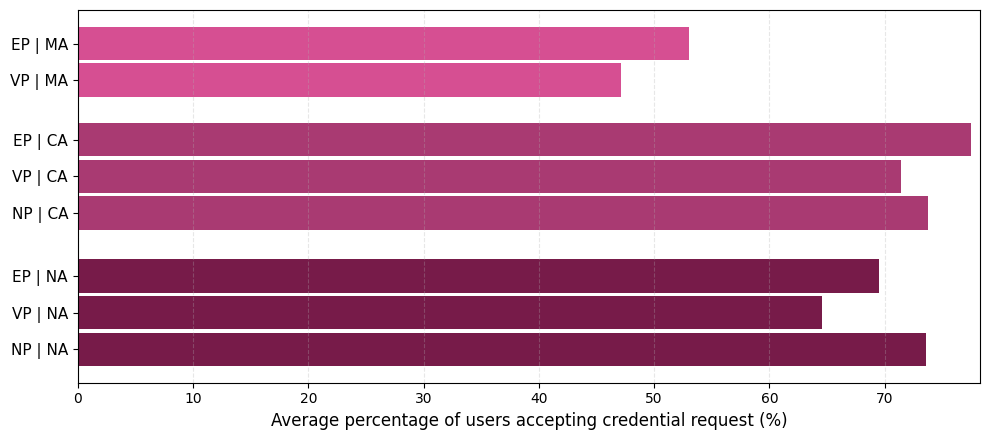

In [26]:
# Chart for cases with a good justification for the website to request the credential; i.e., purposes are in line with justification

with open('data/user_study_results_agg.txt', 'r') as f:
    content = f.read()

s4_match = re.search(r'=== Group S4 ===(.*?)=== Group S5 ===', content, re.DOTALL)
if s4_match:
    s4_content = s4_match.group(1)
    
    np_ca_match = re.search(r'Overall Aggregated for: s4_all_good_no_purpose.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    np_ca = float(np_ca_match.group(1)) if np_ca_match else 73.73
    
    ep_ca_match = re.search(r'Overall Aggregated for: s4_all_good_purpose_proper.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    ep_ca = float(ep_ca_match.group(1)) if ep_ca_match else 77.47
    
    vp_ca_match = re.search(r'Overall Aggregated for: s4_all_good_purpose_vague.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    vp_ca = float(vp_ca_match.group(1)) if vp_ca_match else 71.44
    
    np_na_match = re.search(r'CONTROL scenarios:.*?Aggregated for: s4_all_good_no_purpose.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    np_na = float(np_na_match.group(1)) if np_na_match else 73.58
    
    ep_na_match = re.search(r'CONTROL scenarios:.*?Aggregated for: s4_all_good_purpose_proper.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    ep_na = float(ep_na_match.group(1)) if ep_na_match else 69.49
    
    vp_na_match = re.search(r'CONTROL scenarios:.*?Aggregated for: s4_all_good_purpose_vague.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    vp_na = float(vp_na_match.group(1)) if vp_na_match else 64.58
    
    ep_ma_match = re.search(r'TEST scenarios:.*?Aggregated for: s4_proper.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    ep_ma = float(ep_ma_match.group(1)) if ep_ma_match else 53.00
    
    vp_ma_match = re.search(r'TEST scenarios:.*?Aggregated for: s4_vague.*?Yes: \d+ \(([0-9.]+)%\)', s4_content, re.DOTALL)
    vp_ma = float(vp_ma_match.group(1)) if vp_ma_match else 47.17

labels = [
    'EP | MA',  
    'VP | MA',  
    'EP | CA',  
    'VP | CA',  
    'NP | CA',  
    'EP | NA',  
    'VP | NA',  
    'NP | NA'  
]

data = [
    ep_ma,  
    vp_ma,  
    ep_ca, 
    vp_ca,  
    np_ca, 
    ep_na,  
    vp_na,  
    np_na   
]

print(f"Data read from file: {data}")

light_blue = "#d64f92"
deep_blue = '#a93a72'
purplish_blue = '#771b49'

colors = [light_blue] * 2 + [deep_blue] * 3 + [purplish_blue] * 3

fig, ax = plt.subplots(figsize=(10, 4.5))

y_positions = [
    0.0, 0.55,          
    1.45, 2.0, 2.55,    
    3.5, 4.05, 4.6      
]

bars = ax.barh(y_positions, data, color=colors, height=0.5)

# Customize the chart
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Average percentage of users accepting credential request (%)', fontsize=12)
ax.set_xlim(0, max(data) + 0.8)

ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.invert_yaxis()

plt.tight_layout()

chart_path = 'charts/s4_purpose_credential_chart.pdf'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"Chart saved to {chart_path}")

plt.show()

## Generate figures comparing user sharing when seeing different expert types

Saved chart: charts\group_s3_expert_type_comparison.pdf


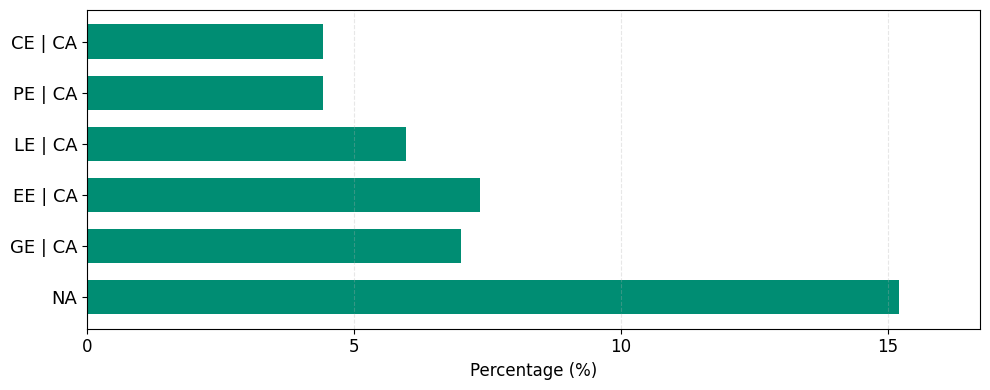

In [27]:
# Case: only shows expert recommendation & no justification for website to request credential

labels = ['NA', 'GE | CA', 'EE | CA', 'LE | CA', 'PE | CA', 'CE | CA']
percentages = [15.20, 7.00, 7.35, 5.97, 4.41, 4.41]

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = np.arange(len(labels)) * 0.3
bars = ax.barh(y_positions, percentages, color="#008D73", height=0.2)
ax.set_yticks(y_positions, labels)

max_val = max(percentages)
ax.set_xlim(0, max_val * 1.1)

ax.tick_params(axis='y', labelsize=13)

ax.set_xticks(np.arange(0, 20, 5))
ax.set_xticklabels([f'{int(x)}' for x in np.arange(0, 20, 5)], fontsize=12)
ax.set_xlabel("Percentage (%)", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

chart_path = OUTPUT_DIR / "group_s3_expert_type_comparison.pdf"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"Saved chart: {chart_path}")
plt.show()

Saved chart: charts\group_s5_expert_type_comparison.pdf


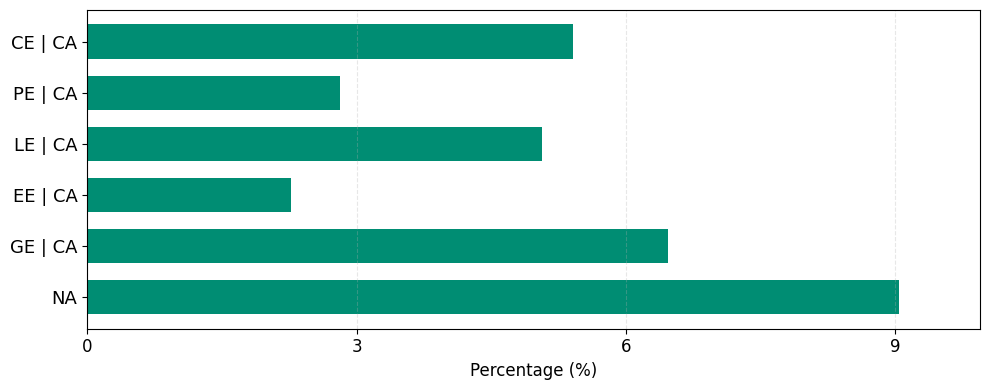

In [28]:
# Case: shows expert recommendation and user opinions & no justification for website to request credential

labels = ['NA', 'GE | CA', 'EE | CA', 'LE | CA', 'PE | CA', 'CE | CA']
percentages = [9.04, 6.47, 2.27, 5.06, 2.82, 5.41]

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = np.arange(len(labels)) * 0.3
bars = ax.barh(y_positions, percentages, color="#008D73", height=0.2)
ax.set_yticks(y_positions, labels)

max_val = max(percentages)
ax.set_xlim(0, max_val * 1.1)

ax.tick_params(axis='y', labelsize=13)

ax.set_xticks(np.arange(0, 12, 3))
ax.set_xticklabels([f'{int(x)}' for x in np.arange(0, 12, 3)], fontsize=12)
ax.set_xlabel("Percentage (%)", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

chart_path = OUTPUT_DIR / "group_s5_expert_type_comparison.pdf"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"Saved chart: {chart_path}")
plt.show()

Saved chart: charts\group_s6_expert_type_comparison.pdf


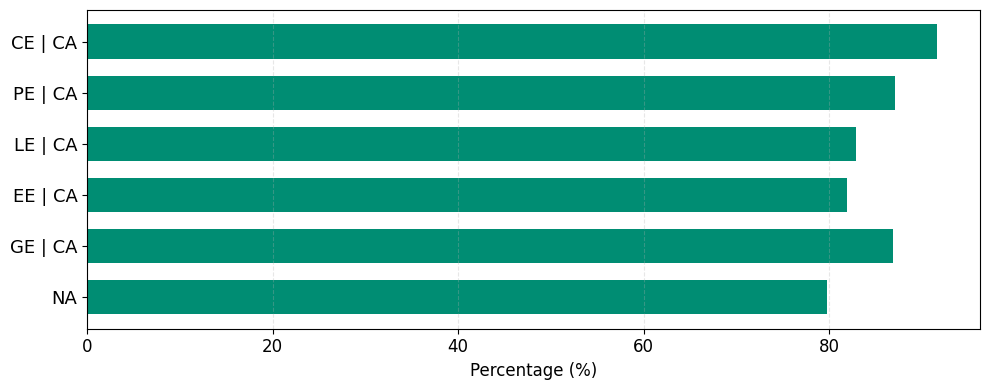

In [29]:
# Case: shows expert recommendation and user opinions & good justification for website to request credential

labels = ['NA', 'GE | CA', 'EE | CA', 'LE | CA', 'PE | CA', 'CE | CA']
percentages = [79.78, 86.86, 81.94, 82.86, 87.10, 91.67]

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = np.arange(len(labels)) * 0.3
bars = ax.barh(y_positions, percentages, color="#008D73", height=0.2)
ax.set_yticks(y_positions, labels)

max_val = max(percentages)
ax.set_xlim(0, max_val * 1.05)

ax.tick_params(axis='y', labelsize=13)

ax.set_xticks(np.arange(0, 100, 20))
ax.set_xticklabels([f'{int(x)}' for x in np.arange(0, 100, 20)], fontsize=12)
ax.set_xlabel("Percentage (%)", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

chart_path = OUTPUT_DIR / "group_s6_expert_type_comparison.pdf"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"Saved chart: {chart_path}")
plt.show()

## Generate figure comparing the charing behavior in the 18-29 group with the 50+ group

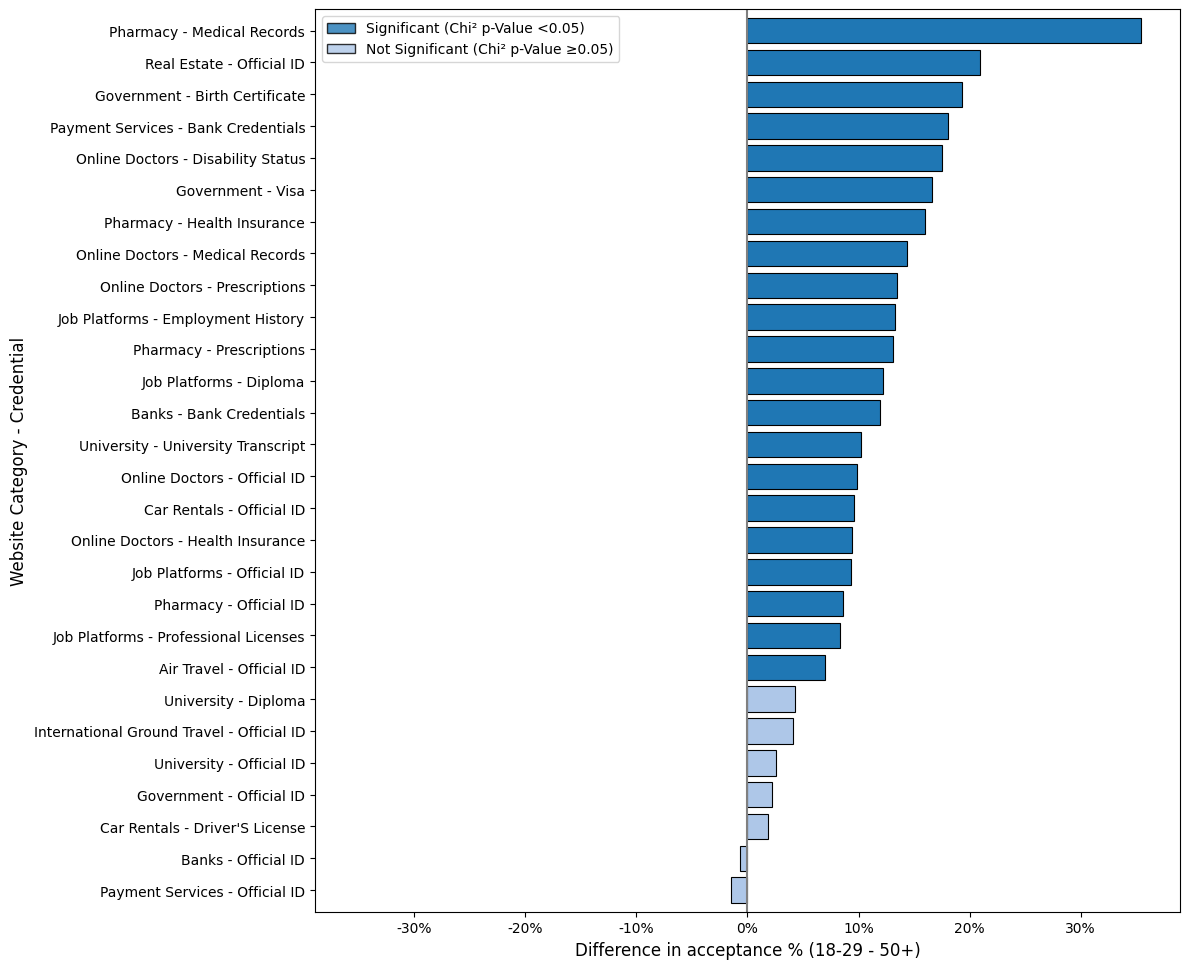

Saved: charts/chi2_age_18_29_vs_50_plus_comparison.pdf


In [30]:
age_df = pd.read_csv('tables/chi2_age_18_29_vs_50_plus.csv')

age_df['age_18_29 Accept %'] = age_df['age_18_29 Accept %'].str.rstrip('%').astype(float)
age_df['age_50_plus Accept %'] = age_df['age_50_plus Accept %'].str.rstrip('%').astype(float)

# Filter: keep only rows where age_18_29 % >= 50% OR age_50_plus % >= 50%
age_df = age_df[((age_df['age_18_29 Accept %'] >= 50) | (age_df['age_50_plus Accept %'] >= 50))].copy()

# Compute difference: age_18_29 % - age_50_plus %
age_df['diff_pct'] = age_df['age_18_29 Accept %'] - age_df['age_50_plus Accept %']

# Rename 'Official Identity Document' to 'Official ID'
age_df['Credential'] = age_df['Credential'].str.replace('Official Identity Document', 'Official ID')

# Capitalize all credential names
age_df['Credential'] = age_df['Credential'].str.title()

# Create label: Website category - Credential
age_df['label'] = age_df['Website category'].str.strip() + ' - ' + age_df['Credential'].str.strip()

# Capitalize 'Id' to 'ID' in labels
age_df['label'] = age_df['label'].str.replace('Id', 'ID')

# Significance flag: p-Value < 0.05
age_df['significant'] = age_df['p-Value'] < 0.05

age_df = age_df.sort_values('diff_pct')

colors_age = ['#1f77b4' if sig else '#aec7e8' for sig in age_df['significant']]

height_age = max(6, 0.35 * len(age_df))
fig, ax = plt.subplots(figsize=(12, height_age))

ax.barh(age_df['label'], age_df['diff_pct'], color=colors_age, edgecolor='black', linewidth=0.8)

ax.axvline(0, color='gray', linestyle='-', linewidth=1.5)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

max_abs_age = max(abs(age_df['diff_pct'].min()), abs(age_df['diff_pct'].max()))
ax.set_xlim(-max_abs_age * 1.1, max_abs_age * 1.1)

ax.margins(y=0.01)

ax.set_xlabel('Difference in acceptance % (18-29 - 50+)', fontsize=12)
ax.set_ylabel('Website Category - Credential', fontsize=12)

legend_elements_age = [
    Patch(facecolor='#1f77b4', edgecolor='black', alpha=0.8, label='Significant (Chi² p-Value <0.05)'),
    Patch(facecolor='#aec7e8', edgecolor='black', alpha=0.8, label='Not Significant (Chi² p-Value ≥0.05)')
]
ax.legend(handles=legend_elements_age, fontsize=10, loc='best')

plt.tight_layout()

age_chart_path = 'charts/chi2_age_18_29_vs_50_plus_comparison.pdf'
plt.savefig(age_chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {age_chart_path}")


## Generate figures showing the demographic breakdown of participants

In [31]:
# User survey participant demographics

def parse_demographics_block(path, keys):
    data = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if ':' not in line:
                continue
            k, v = line.split(':', 1)
            k = k.strip()
            v = v.strip()
            try:
                data[k] = int(v)
            except ValueError:
                continue
    return {k: data.get(k, 0) for k in keys}

demo_file = 'aggregate_demographics_data/user_survey_demographics.txt'
gender_keys = ['female', 'male', 'other_gender']
gender_data = parse_demographics_block(demo_file, gender_keys)

plt.figure(figsize=(6, 6))
gender_labels = ['Female', 'Male', 'Other']
gender_values = list(gender_data.values())
gender_pcts = [100.0 * v / sum(gender_values) for v in gender_values]
gender_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(gender_labels, gender_pcts)]
gender_colors = ['#ffd4a3', '#ff9f4f', '#ff6b35']
wedges, texts = plt.pie(gender_values, labels=gender_pie_labels, startangle=140, colors=gender_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if gender_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
gender_path = os.path.join(OUTPUT_DIR, 'user_survey_demographics_gender_pie.pdf')
plt.savefig(gender_path, bbox_inches='tight')
plt.close()
print(f'Saved {gender_path}')

age_keys = ['age_18_29', 'age_30_49', 'age_50_plus']
age_data = parse_demographics_block(demo_file, age_keys)

plt.figure(figsize=(6, 6))
age_labels = ['18-29', '30-49', '50+']
age_values = list(age_data.values())
age_pcts = [100.0 * v / sum(age_values) for v in age_values]
age_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(age_labels, age_pcts)]
age_colors = ['#d4edda', '#66bb6a', '#2e7d32']
wedges, texts = plt.pie(age_values, labels=age_pie_labels, startangle=140, colors=age_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if age_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
age_path = os.path.join(OUTPUT_DIR, 'user_survey_demographics_age_pie.pdf')
plt.savefig(age_path, bbox_inches='tight')
plt.close()
print(f'Saved {age_path}')

edu_keys = ['hs', 'bsc', 'msc', 'phd']
edu_data = parse_demographics_block(demo_file, edu_keys)

plt.figure(figsize=(6, 6))
edu_labels = ['High School', 'Bachelor', 'Master', 'PhD']
edu_values = list(edu_data.values())
edu_pcts = [100.0 * v / sum(edu_values) for v in edu_values]
edu_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(edu_labels, edu_pcts)]
edu_colors = ['#b8d8f2', '#7aafe0', '#9174c4', '#6b3d9e']
wedges, texts = plt.pie(edu_values, labels=edu_pie_labels, startangle=140, colors=edu_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if edu_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
edu_path = os.path.join(OUTPUT_DIR, 'user_survey_demographics_education_pie.pdf')
plt.savefig(edu_path, bbox_inches='tight')
plt.close()
print(f'Saved {edu_path}')

residency_keys = ['france', 'germany', 'italy']
residency_data = parse_demographics_block(demo_file, residency_keys)

plt.figure(figsize=(6, 6))
residency_labels = ['France', 'Germany', 'Italy']
residency_values = list(residency_data.values())
residency_pcts = [100.0 * v / sum(residency_values) for v in residency_values]
residency_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(residency_labels, residency_pcts)]
residency_colors = ['#b2dfdb', '#4db6ac', '#00796b']
wedges, texts = plt.pie(residency_values, labels=residency_pie_labels, startangle=140, colors=residency_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if residency_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
residency_path = os.path.join(OUTPUT_DIR, 'user_survey_demographics_residency_pie.pdf')
plt.savefig(residency_path, bbox_inches='tight')
plt.close()
print(f'Saved {residency_path}')

Saved charts\user_survey_demographics_gender_pie.pdf
Saved charts\user_survey_demographics_age_pie.pdf
Saved charts\user_survey_demographics_education_pie.pdf
Saved charts\user_survey_demographics_residency_pie.pdf


In [32]:
# User study participant demographics

def parse_demographics_block(path, keys):
    data = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if ':' not in line:
                continue
            k, v = line.split(':', 1)
            k = k.strip()
            v = v.strip()
            try:
                data[k] = int(v)
            except ValueError:
                continue
    return {k: data.get(k, 0) for k in keys}

demo_file = 'aggregate_demographics_data/user_study_demographics.txt'
gender_keys = ['female', 'male', 'other_gender']
gender_data = parse_demographics_block(demo_file, gender_keys)

plt.figure(figsize=(6, 6))
gender_labels = ['Female', 'Male', 'Other']
gender_values = list(gender_data.values())
gender_pcts = [100.0 * v / sum(gender_values) for v in gender_values]
gender_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(gender_labels, gender_pcts)]
gender_colors = ['#ffd4a3', '#ff9f4f', '#ff6b35']
wedges, texts = plt.pie(gender_values, labels=gender_pie_labels, startangle=140, colors=gender_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if gender_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
gender_path = os.path.join(OUTPUT_DIR, 'user_study_demographics_gender_pie.pdf')
plt.savefig(gender_path, bbox_inches='tight')
plt.close()
print(f'Saved {gender_path}')

age_keys = ['age_18_29', 'age_30_49', 'age_50_plus']
age_data = parse_demographics_block(demo_file, age_keys)

plt.figure(figsize=(6, 6))
age_labels = ['18-29', '30-49', '50+']
age_values = list(age_data.values())
age_pcts = [100.0 * v / sum(age_values) for v in age_values]
age_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(age_labels, age_pcts)]
age_colors = ['#d4edda', '#66bb6a', '#2e7d32']
wedges, texts = plt.pie(age_values, labels=age_pie_labels, startangle=140, colors=age_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if age_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
age_path = os.path.join(OUTPUT_DIR, 'user_study_demographics_age_pie.pdf')
plt.savefig(age_path, bbox_inches='tight')
plt.close()
print(f'Saved {age_path}')

edu_keys = ['hs', 'bsc', 'msc', 'phd']
edu_data = parse_demographics_block(demo_file, edu_keys)

plt.figure(figsize=(6, 6))
edu_labels = ['High School', 'Bachelor', 'Master', 'PhD']
edu_values = list(edu_data.values())
edu_pcts = [100.0 * v / sum(edu_values) for v in edu_values]
edu_pie_labels = [f'{label}:\n{pct:.1f}%' for label, pct in zip(edu_labels, edu_pcts)]
edu_colors = ['#b8d8f2', '#7aafe0', '#9174c4', '#6b3d9e']
wedges, texts = plt.pie(edu_values, labels=edu_pie_labels, startangle=140, colors=edu_colors,
                         labeldistance=1.05, textprops={'fontsize': 12})
for i, text in enumerate(texts):
    label_parts = text.get_text().split('\n')
    bold_label = label_parts[0].replace(":", "").replace(" ", "\\ ")
    text.set_text(f'$\\mathbf{{{bold_label}}}$:\n{label_parts[1]}')
    text.set_fontsize(12)
for i, (wedge, text) in enumerate(zip(wedges, texts)):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = wedge.r * 0.7 * np.cos(np.radians(angle))
    y = wedge.r * 0.7 * np.sin(np.radians(angle))
    if edu_pcts[i] > 10:
        text.set_position((x, y))
        text.set_horizontalalignment('center')
        text.set_color('black')
plt.axis('equal')
edu_path = os.path.join(OUTPUT_DIR, 'user_study_demographics_education_pie.pdf')
plt.savefig(edu_path, bbox_inches='tight')
plt.close()
print(f'Saved {edu_path}')


Saved charts\user_study_demographics_gender_pie.pdf
Saved charts\user_study_demographics_age_pie.pdf
Saved charts\user_study_demographics_education_pie.pdf
